<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);
     padding:36px 30px 28px 30px;border-radius:10px;">
  <h1 style="color:#FFFFFF;margin:0 0 8px 0;font-size:1.85em;font-weight:700;">
    Financial Risk Management and Engineering — Session 5: Credit Risk I — Default Probability, Spreads &amp; Ratings</h1>
  <h2 style="color:#A9D0F5;margin:0 0 14px 0;font-size:1.15em;font-weight:400;">
    Merton Structural Model · Distance to Default · Credit Spreads · Rating Transitions</h2>
  <div style="color:#7DB5D8;font-size:0.92em;">
    Aarhus Summer University &nbsp;·&nbsp; July 2026
  </div>
</div>

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">About this notebook</div>
<div style="color:#B8D4E8;line-height:1.7;">We implement the <strong>Merton (1974) structural model</strong> — the workhorse of credit risk analytics. The central insight: <em>equity is a call option on the firm's assets</em>. From observable equity prices and balance-sheet debt we back out the implied default probability and credit spread.<br><br>
We also cover credit ratings, historical default rates, and the one-year S&amp;P rating transition matrix.</div>
</div>

**Key equations covered:**

$$E = V \cdot N(d_1) - D \cdot e^{-rT} \cdot N(d_2) \qquad \text{(equity as call on assets)}$$

$$\sigma_E \cdot E = N(d_1) \cdot \sigma_V \cdot V \qquad \text{(equity vol linkage)}$$

$$\text{DD} = \frac{\ln(V/D) + (\mu - \tfrac{1}{2}\sigma_V^2)T}{\sigma_V \sqrt{T}}, \quad \text{PD} = N(-\text{DD}), \quad s = -\frac{1}{T}\ln(1 - \text{PD} \cdot \text{LGD})$$


*Reference: Hull (2023) Ch. 17 (Estimating Default Probabilities); Jorion (2010) Financial Risk Manager Handbook, Ch. 19 (Introduction to Credit Risk).*

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup &mdash; Required Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy scikit-learn xlrd openpyxl
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser. Upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy scikit-learn xlrd openpyxl`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'seaborn', 'sklearn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3
  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1
  yfinance      0.2.55
  seaborn       0.13.2
  sklearn       1.8.0


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> &mdash; order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute &mdash; this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats, optimize
from scipy.stats import norm
import yfinance as yf

# ── Black-Scholes call (Merton reuses the BS call formula) ─────────────────────
from scipy.stats import norm as _norm
def bs_call_value(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0 or S <= 0: return max(S - K, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*_norm.cdf(d1) - K*np.exp(-r*T)*_norm.cdf(d2)
def bs_call_delta(S, K, T, r, sigma):     # = N(d1)
    if T <= 0 or sigma <= 0 or S <= 0: return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return _norm.cdf(d1)
print("Black-Scholes helpers defined (inline).")

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
NAVY  = '#0D2B55'
BLUE  = '#2C7BB6'
GREEN = '#1A9641'
RED   = '#D7191C'
GOLD  = '#D4A017'

# ── Data parameters ───────────────────────────────────────────────────────────
START      = '2021-07-01'
END        = '2026-07-01'
RF_ANNUAL  = 0.04
TICKERS    = ['MSFT', 'LUMN', 'AMC', 'BYND']   # one solid firm plus three distressed, high-PD names

print(f"Setup complete.")
print(f"Date window: {START} → {END}")
print(f"Risk-free rate (annual): {RF_ANNUAL*100:.1f}%")
print(f"Merton universe: {TICKERS}")

Black-Scholes helpers defined (inline).
Setup complete.
Date window: 2021-07-01 → 2026-07-01
Risk-free rate (annual): 4.0%
Merton universe: ['MSFT', 'LUMN', 'AMC', 'BYND']


## Data setup (run once; needs internet on the first run)

This notebook is self-contained: it does not rely on any files from the instructor's computer.
The cell below builds a local `notebook_data/` folder next to the notebook and fills it with
everything the notebook needs.

- Small published tables (the S&P transition matrix, Moody's default and recovery rates, the
  rating benchmarks, and the EDGAR-derived firm inputs) are **embedded in the cell**, so they
  always work, even with no internet.
- Larger or time-varying data (ICE BofA credit spreads and the Treasury curve from FRED, and the
  UCI credit-card dataset) is **downloaded the first time you run it**.

If a file already exists it is kept, so re-running is cheap. Stock prices are handled in the next
section (downloaded from Yahoo, with a built-in fallback if Yahoo is busy).

In [3]:
# Small published tables, embedded verbatim so they work with no download:
_EMB = {}
_EMB["sp_transition_1981_2024.csv"] = """,AAA,AA,A,BBB,BB,B,CCC/C,D,NR
AAA,87.28,8.92,0.51,0.03,0.1,0.03,0.05,0.0,3.08
AA,0.45,87.74,7.5,0.44,0.05,0.06,0.02,0.02,3.74
A,0.02,1.48,89.42,4.64,0.23,0.1,0.01,0.05,4.04
BBB,0.0,0.07,3.05,87.33,3.21,0.4,0.09,0.14,5.71
BB,0.01,0.02,0.1,4.44,78.89,6.25,0.5,0.56,9.23
B,0.0,0.02,0.06,0.14,4.47,75.18,4.79,2.93,12.41
CCC/C,0.0,0.0,0.07,0.13,0.4,13.18,45.07,26.12,15.03
"""
_EMB["moodys_cum_default_1970_2013.csv"] = """,1,2,3,4,5,7,10,15,20
Aaa,0.0,0.013,0.013,0.037,0.104,0.241,0.489,0.91,1.073
Aa,0.022,0.068,0.136,0.26,0.41,0.682,1.017,1.871,3.167
A,0.062,0.199,0.434,0.679,0.958,1.615,2.759,4.583,7.044
Baa,0.174,0.504,0.906,1.373,1.862,2.872,4.623,8.306,11.969
Ba,1.11,3.071,5.371,7.839,10.065,13.911,19.323,28.5,35.41
B,3.904,9.274,14.723,19.509,23.869,31.774,40.56,50.275,55.892
Caa-C,15.894,27.003,35.8,42.796,48.828,56.878,66.212,73.152,74.946
"""
_EMB["moodys_cum_default_1983_2023.csv"] = """,1,2,3,5,10
Aaa,0.0,0.01,0.01,0.08,0.09
Aa,0.02,0.06,0.11,0.29,0.67
A,0.06,0.15,0.29,0.61,1.41
Baa,0.15,0.4,0.7,1.39,3.02
Ba,0.84,2.33,4.11,7.82,15.0
B,3.19,7.51,11.9,19.0,28.3
Caa-C,10.2,17.6,23.8,31.9,40.0
"""
_EMB["moodys_recovery_1982_2013.csv"] = """seniority,recovery_pct
Senior secured,52.2
Senior unsecured,37.2
Senior subordinated,31.0
Subordinated,31.4
Junior subordinated,24.7
"""
_EMB["sp_ratio_medians.csv"] = """Rating,EBIT_cov,EBITDA_cov,FFO_debt,FOCF_debt,PretaxROC,OperMargin,TotDebt_cap
AAA,23.4,25.3,214.2,156.6,35.0,23.4,22.9
AA,13.3,16.5,65.7,33.6,26.6,24.0,37.7
A,6.3,8.5,42.2,20.1,18.1,18.1,42.5
BBB,3.9,5.4,30.6,10.4,13.6,15.5,48.2
BB,2.2,3.2,19.2,3.2,11.6,15.4,62.6
B,1.0,1.7,9.4,-2.0,6.6,11.2,74.8
CCC,0.4,0.9,5.8,-4.1,2.6,13.6,87.7
"""
_EMB["edgar_altman.csv"] = """Ticker,CA,CL,TA,RE,EBIT,Rev,TL,BookEq,MCap,Rating,FY
MSFT,191131000000,141218000000,619003000000,237731000000,128528000000,281724000000,275524000000,343479000000,2860,AAA,2025-06-30
AAPL,147957000000,165631000000,359241000000,-14264000000,133050000000,416161000000,285508000000,73733000000,4630,AA+,2025-09-27
XOM,83382000000,72330000000,448980000000,482494000000,41871000000,276692000000,182354000000,259386000000,570,AA-,2025-12-31
WMT,84874000000,107469000000,284668000000,104774000000,29825000000,706413000000,178781000000,99617000000,895,AA,2026-01-31
F,123487000000,114890000000,289160000000,22508000000,-9169000000,187267000000,253180000000,35952000000,54,BBB-,2025-12-31
AAL,12205000000,24492000000,61774000000,-6732000000,1467000000,54633000000,65501000000,-3727000000,11,B+,2025-12-31
"""
_EMB["edgar_ratios.csv"] = """Ticker,EBIT,DA,Interest,NI,Capex,Rev,LTD,DebtCur,TotalDebt,BookEq,EqNCI,TA,PrefStock,Rating,FY
MSFT,128528000000.0,28000000000.0,2935000000,101832000000,64551000000,281724000000,40152000000,2999000000.0,43151000000,343479000000,,619003000000,,AAA,2025-06-30
AAPL,133050000000.0,11698000000.0,3933000000,112010000000,12715000000,416161000000,78328000000,12350000000.0,90678000000,73733000000,,359241000000,,AA+,2025-09-27
XOM,,25993000000.0,603000000,28844000000,28358000000,276692000000,23100000000,6200000000.0,29300000000,259386000000,266626000000.0,448980000000,,AA-,2025-12-31
WMT,29825000000.0,10678000000.0,2318000000,21893000000,26642000000,706413000000,34624000000,3542000000.0,38166000000,99617000000,105887000000.0,284668000000,0.0,AA,2026-01-31
F,-9169000000.0,15974000000.0,7613000000,5879000000,8815000000,187267000000,291000000,,158900000000,35952000000,35980000000.0,289160000000,,BBB-,2025-12-31
AAL,1467000000.0,2200000000.0,2145000000,111000000,3779000000,54633000000,6735000000,3641000000.0,10376000000,-3727000000,,61774000000,3833000000.0,B+,2025-12-31
"""

import io, subprocess, sys, os

DATA_DIR  = "notebook_data"          # relative folder next to this notebook
CACHE_DIR = DATA_DIR                  # alias used later in the notebook
os.makedirs(DATA_DIR, exist_ok=True)
def _p(fn):    return os.path.join(DATA_DIR, fn)
def _need(fn): return not os.path.exists(_p(fn))

# (1) Write the embedded tables (only if missing).
for _fn, _txt in _EMB.items():
    if _need(_fn):
        with open(_p(_fn), "w") as _f: _f.write(_txt)

# (2) ICE BofA credit spreads by rating and maturity, live from FRED (if missing).
_SPREADS = {
    "IG_1_3y":"BAMLC1A0C13Y","IG_3_5y":"BAMLC2A0C35Y","IG_5_7y":"BAMLC3A0C57Y",
    "IG_7_10y":"BAMLC4A0C710Y","IG_10_15y":"BAMLC7A0C1015Y",
    "AAA":"BAMLC0A1CAAA","AA":"BAMLC0A2CAA","A_":"BAMLC0A3CA","BBB":"BAMLC0A4CBBB",
    "BB":"BAMLH0A1HYBB","B":"BAMLH0A2HYB","CCC":"BAMLH0A3HYC",
}   # FRED multi-series caps at 12; masters not needed by this notebook
if _need("credit_spreads_fred.csv"):
    try:
        _o = subprocess.run(["curl","-sf","--max-time","60",
             "https://fred.stlouisfed.org/graph/fredgraph.csv?id="+",".join(_SPREADS.values())],
             capture_output=True, text=True)
        _raw = pd.read_csv(io.StringIO(_o.stdout), parse_dates=[0], index_col=0)
        _raw = _raw.apply(pd.to_numeric, errors="coerce").rename(columns={v:k for k,v in _SPREADS.items()})
        _raw.reindex(columns=list(_SPREADS)).to_csv(_p("credit_spreads_fred.csv"))
        print("Downloaded credit spreads from FRED.")
    except Exception as _e:
        print("Could not fetch credit spreads from FRED:", str(_e)[:70])

# (3) Treasury constant-maturity yield snapshot, live from FRED (if missing).
if _need("treasury_curve_fred.csv"):
    try:
        _tv, _asof = {}, None
        for _m, _sid in {1:"DGS1",2:"DGS2",3:"DGS3",5:"DGS5",7:"DGS7",10:"DGS10"}.items():
            _o = subprocess.run(["curl","-sf","--max-time","30",
                 "https://fred.stlouisfed.org/graph/fredgraph.csv?id="+_sid], capture_output=True, text=True)
            _d = pd.read_csv(io.StringIO(_o.stdout))
            _v = pd.to_numeric(_d.iloc[:,1], errors="coerce"); _ok = _v.notna()
            _tv[_m] = round(float(_v[_ok].iloc[-1]),2); _asof = str(_d.loc[_ok].iloc[-1,0])
        _td = pd.DataFrame([_tv], index=["yield_pct"]); _td.index.name = "asof_"+str(_asof)
        _td.to_csv(_p("treasury_curve_fred.csv"))
        print("Downloaded Treasury curve from FRED (as of "+str(_asof)+").")
    except Exception as _e:
        print("Could not fetch Treasury curve from FRED:", str(_e)[:70])

# (4) UCI credit-card default dataset, from the UCI archive (if missing).
if _need("uci_credit_default.csv"):
    try:
        try: import xlrd  # noqa: needed to read the .xls
        except ImportError: subprocess.run([sys.executable,"-m","pip","install","-q","xlrd"])
        import zipfile
        subprocess.run(["curl","-sL","--max-time","120","-o",_p("_uci.zip"),
            "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"])
        with zipfile.ZipFile(_p("_uci.zip")) as _z:
            with _z.open(_z.namelist()[0]) as _fh:
                _uci = pd.read_excel(_fh, header=1)
        _uci.to_csv(_p("uci_credit_default.csv"), index=False)
        os.remove(_p("_uci.zip"))
        print("Downloaded UCI credit dataset:", _uci.shape)
    except Exception as _e:
        print("Could not build UCI dataset ("+str(_e)[:70]+"); the logistic scorecard will be skipped.")

print("Data setup complete. Using data folder:", os.path.abspath(DATA_DIR))

Data setup complete. Using data folder: /Users/yuriyzabolotnyuk/Library/CloudStorage/OneDrive-CarletonUniversity/Aarhus/Financial Risk Management 2026/Session Materials/notebook_data


## Part 1 — Data Download & Equity Return Estimation

<div style="border-left:5px solid #1A9641;background:#0A1F10;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#52C97A;font-weight:700;margin-bottom:7px;">Why yfinance for credit risk?</div>
<div style="color:#A8D8B0;line-height:1.7;">The Merton model requires two observable inputs: <strong>equity market capitalisation</strong> (= share price × shares outstanding) and <strong>total debt</strong> from the balance sheet. Both are available from <code>yf.Ticker.info</code>. Equity volatility σ<sub>E</sub> is estimated from the rolling history of log returns.</div>
</div>

In [4]:
# ── Cache path ────────────────────────────────────────────────────────────────
CACHE_DIR  = "notebook_data"          # relative folder (created by the Data setup cell above)
CACHE_FILE = os.path.join(CACHE_DIR, "Session_05_data.csv")
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Robust download with 3 retries ────────────────────────────────────────────
def download_with_retry(tickers, start, end, retries=3, wait=5):
    for attempt in range(1, retries + 1):
        try:
            raw = yf.download(tickers, start=start, end=end,
                              auto_adjust=True, progress=False)
            prices = raw['Close'].dropna(how='all')
            if not prices.empty:
                return prices
        except Exception as e:
            print(f"  Attempt {attempt}/{retries} failed: {e}")
            if attempt < retries:
                time.sleep(wait)
    return None

# ── Load from cache or download ───────────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    prices = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
    print(f"Loaded cached data: {prices.shape} from {CACHE_FILE}")
else:
    print("Downloading price data ...")
    prices = download_with_retry(TICKERS, START, END)
    if prices is not None:
        prices.to_csv(CACHE_FILE)
        print(f"Saved to cache: {CACHE_FILE}")
    else:
        print("Download failed — generating synthetic fallback prices")
        np.random.seed(42)
        idx = pd.bdate_range(START, END)
        # (start price, daily vol) per firm; the distressed names carry much higher volatility
        base = {'MSFT': (290, 0.018), 'LUMN': (12, 0.050), 'AMC': (10, 0.065), 'BYND': (25, 0.070)}
        prices = pd.DataFrame(
            {t: base[t][0] * np.exp(np.cumsum(np.random.normal(0.0, base[t][1], len(idx))))
             for t in TICKERS}, index=idx)

# ── Log returns ───────────────────────────────────────────────────────────────
log_ret = np.log(prices / prices.shift(1)).dropna()
ann_vol = log_ret.std() * np.sqrt(252)

print(f"\nPrice data: {len(prices)} rows, {prices.index[0].date()} to {prices.index[-1].date()}")
print("\nAnnualised equity volatility (σ_E):")
for t in TICKERS:
    print(f"  {t:5s}: {ann_vol[t]*100:.1f}%")

Loaded cached data: (1247, 4) from notebook_data/Session_05_data.csv

Price data: 1247 rows, 2021-07-14 to 2026-07-01

Annualised equity volatility (σ_E):
  MSFT : 27.1%
  LUMN : 80.3%
  AMC  : 101.9%
  BYND : 109.0%


In [5]:
# ── Fetch equity value (market cap) and total debt from yfinance ──────────────
# Hard-coded fallbacks guarantee execution even if yfinance .info is unavailable.

# Fallback values (approximate figures as of 2025-2026)
FALLBACK = {
    'MSFT': {'market_cap': 2.90e12, 'total_debt': 4.03e10},   # solid, low PD (contrast)
    'LUMN': {'market_cap': 6.65e9,  'total_debt': 3.15e10},   # very high leverage telecom
    'AMC':  {'market_cap': 1.14e9,  'total_debt': 4.02e9},    # high leverage plus high vol
    'BYND': {'market_cap': 3.20e8,  'total_debt': 4.10e8},    # high vol, cash burn
}

firm_data = {}
for ticker in TICKERS:
    fb = FALLBACK[ticker]
    market_cap = fb['market_cap']
    total_debt = fb['total_debt']
    source     = 'fallback'

    try:
        tk   = yf.Ticker(ticker)
        info = tk.info

        # Market cap: prefer marketCap, compute from price × shares if needed
        mc_live = info.get('marketCap')
        if mc_live and mc_live > 1e8:
            market_cap = float(mc_live)
            source = 'yfinance.info'

        # Total debt: try info first, then balance sheet
        td_live = info.get('totalDebt')
        if td_live and td_live > 0:
            total_debt = float(td_live)
        else:
            bs = tk.balance_sheet
            if bs is not None and not bs.empty:
                for row_label in ['Total Debt', 'Long Term Debt And Capital Lease Obligation',
                                  'Long Term Debt', 'Total Long Term Debt']:
                    if row_label in bs.index:
                        val = bs.loc[row_label].iloc[0]
                        if pd.notna(val) and val > 0:
                            total_debt = float(val)
                            break

    except Exception as e:
        print(f"  [{ticker}] yfinance error, using fallback ({e})")

    sigma_e = float(ann_vol[ticker])
    firm_data[ticker] = {
        'E':       market_cap,
        'D':       total_debt,
        'sigma_E': sigma_e,
        'source':  source,
    }

# Summary
print(f"{'Ticker':6s} {'Equity ($B)':>14s} {'Debt ($B)':>12s} {'σ_E (%)':>10s} {'Leverage':>12s} {'Source':>14s}")
print("-" * 70)
for t, d in firm_data.items():
    lev = d['D'] / (d['E'] + d['D'])
    print(f"{t:6s} {d['E']/1e9:>14.1f} {d['D']/1e9:>12.1f} {d['sigma_E']*100:>10.1f}%{lev:>12.1%}  {d['source']:>14s}")

  [MSFT] yfinance error, using fallback ('str' object has no attribute 'name')
  [LUMN] yfinance error, using fallback ('str' object has no attribute 'name')
  [AMC] yfinance error, using fallback ('str' object has no attribute 'name')
  [BYND] yfinance error, using fallback ('str' object has no attribute 'name')
Ticker    Equity ($B)    Debt ($B)    σ_E (%)     Leverage         Source
----------------------------------------------------------------------
MSFT           2900.0         40.3       27.1%        1.4%        fallback
LUMN              6.7         31.5       80.3%       82.6%        fallback
AMC               1.1          4.0      101.9%       77.9%        fallback
BYND              0.3          0.4      109.0%       56.2%        fallback


## Part 2 — Credit Ratings, Historical Default Rates & Transition Matrices

Before the structural model, anchor on **empirical, real-world data**: how often do firms
at each rating actually default, how do ratings drift over a year, and how much is recovered
in default? Every table below is loaded from the published rating-agency studies (cached in
`notebook_data/`), not illustrative guesses.

<div style="border-left:5px solid #D4A017;background:#1C1200;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#D4A017;font-weight:700;margin-bottom:7px;">Real data sources</div>
<div style="color:#F5CBA7;line-height:1.7;">
<strong>Default rates</strong> — Moody's average cumulative default rates 1970-2013 (Hull, <em>Risk Management and Financial Institutions</em>, Table 19.1).<br>
<strong>Transition matrix</strong> — S&amp;P Global Ratings, <em>2024 Annual Global Corporate Default And Rating Transition Study</em> (Table 21, one-year global average, 1981-2024).<br>
<strong>Recovery</strong> — Moody's issuer-weighted recovery by seniority 1982-2013 (Hull Table 19.2).<br>
The Merton model then gives a <em>market-implied</em> PD we can compare against these historical anchors.</div>
</div>

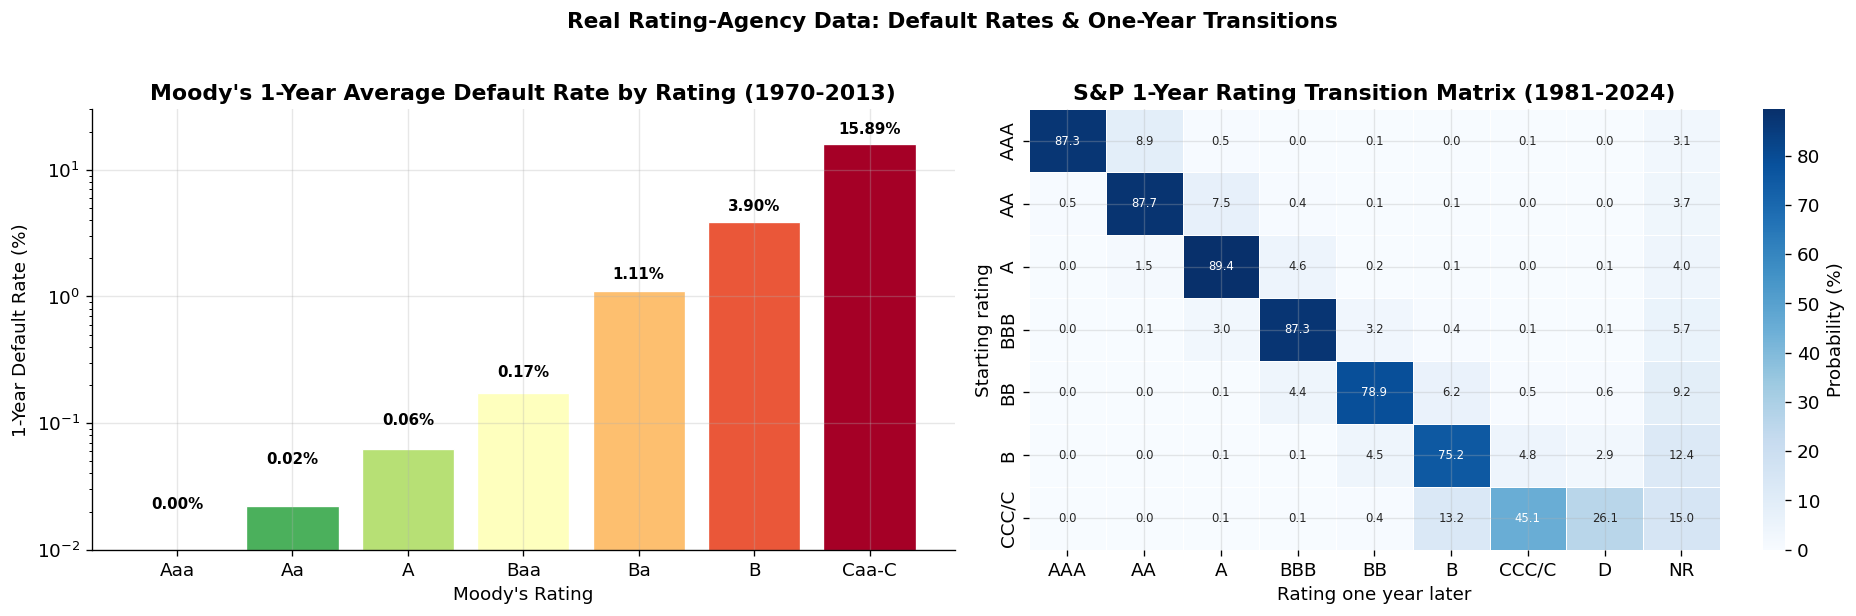

Recovery by seniority (Moody's 1982-2013):
  Senior secured        : recovery 52.2%  ->  LGD 47.8%
  Senior unsecured      : recovery 37.2%  ->  LGD 62.8%
  Senior subordinated   : recovery 31.0%  ->  LGD 69.0%
  Subordinated          : recovery 31.4%  ->  LGD 68.6%
  Junior subordinated   : recovery 24.7%  ->  LGD 75.3%

Using senior-unsecured LGD = 62.8% for expected loss.

Expected Annual Loss  EL = PD x LGD
----------------------------------------------
  Aaa     : PD =   0.00%   EL = 0.000%
  Aa      : PD =   0.02%   EL = 0.014%
  A       : PD =   0.06%   EL = 0.039%
  Baa     : PD =   0.17%   EL = 0.109%
  Ba      : PD =   1.11%   EL = 0.697%
  B       : PD =   3.90%   EL = 2.452%
  Caa-C   : PD =  15.89%   EL = 9.981%

Reading the matrix: a BBB issuer has a 3.84% chance of being junk-rated or in default within one year
(vs 0.14% outright default) — migration risk, not just default risk.


In [6]:
# ── Real rating-agency data (loaded from cached published studies) ────────────
REF_DIR = CACHE_DIR   # notebook_data/ holds the published reference tables

# 1) Moody's average cumulative default rates, 1970-2013 (Hull Table 19.1)
cum_def = pd.read_csv(os.path.join(REF_DIR, "moodys_cum_default_1970_2013.csv"), index_col=0)
ratings_moodys = list(cum_def.index)                 # Aaa … Caa-C
default_rates  = cum_def["1"].values                 # 1-year default rate (%)

# 2) S&P 1-year average transition matrix, 1981-2024 (S&P 2024 Default & Transition Study, Table 21)
trans = pd.read_csv(os.path.join(REF_DIR, "sp_transition_1981_2024.csv"), index_col=0)
rating_labels  = list(trans.columns)                 # AAA … CCC/C, D, NR
transition_pct = trans.values

# 3) Moody's recovery rates by seniority, 1982-2013 (Hull Table 19.2)
recov = pd.read_csv(os.path.join(REF_DIR, "moodys_recovery_1982_2013.csv"))
# Representative LGD for a senior unsecured claim = 1 - recovery
REC_SEN_UNSEC = float(recov.loc[recov.seniority=="Senior unsecured","recovery_pct"].iloc[0]) / 100
LGD_AVG = 1 - REC_SEN_UNSEC

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel 1: real 1-year default rate by rating (log scale spans 0.02%→16%) ──
bar_colors = [cm.RdYlGn(1.0 - i/(len(ratings_moodys)-1)) for i in range(len(ratings_moodys))]
bars = axes[0].bar(ratings_moodys, default_rates, color=bar_colors,
                   edgecolor='white', linewidth=0.8)
axes[0].set_title("Moody's 1-Year Average Default Rate by Rating (1970-2013)", fontweight='bold')
axes[0].set_ylabel('1-Year Default Rate (%)')
axes[0].set_xlabel("Moody's Rating")
for bar, dr in zip(bars, default_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.15+0.02,
                 f'{dr:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_yscale('log'); axes[0].set_ylim(0.01, 30)

# ── Panel 2: real S&P one-year transition matrix ──
sns.heatmap(transition_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=rating_labels, yticklabels=list(trans.index),
            ax=axes[1], cbar_kws={'label': 'Probability (%)'}, linewidths=0.3,
            annot_kws={'size':7})
axes[1].set_title('S&P 1-Year Rating Transition Matrix (1981-2024)', fontweight='bold')
axes[1].set_xlabel('Rating one year later'); axes[1].set_ylabel('Starting rating')

plt.suptitle('Real Rating-Agency Data: Default Rates & One-Year Transitions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Recovery / LGD and expected annual loss by rating ──
print("Recovery by seniority (Moody's 1982-2013):")
for _, r in recov.iterrows():
    print(f"  {r.seniority:22s}: recovery {r.recovery_pct:4.1f}%  ->  LGD {100-r.recovery_pct:4.1f}%")
print(f"\nUsing senior-unsecured LGD = {LGD_AVG:.1%} for expected loss.")
print("\nExpected Annual Loss  EL = PD x LGD")
print("-"*46)
for r, pd_r in zip(ratings_moodys, default_rates):
    print(f"  {r:8s}: PD = {pd_r:6.2f}%   EL = {pd_r/100*LGD_AVG*100:.3f}%")

# Probability an investment-grade (BBB) issuer is downgraded to junk within 1 year:
bbb = trans.loc["BBB"]
ig_to_hy = bbb[["BB","B","CCC/C","D"]].sum()
print(f"\nReading the matrix: a BBB issuer has a {ig_to_hy:.2f}% chance of being "
      f"junk-rated or in default within one year\n(vs {bbb['D']:.2f}% outright default) "
      "— migration risk, not just default risk.")

### A note on the sample window: Moody's 1970-2013 vs 1983-2023

The default table above is Moody's **1970-2013** study (Hull Table 19.1). It includes the
high-default 1970s-80s. Moody's more recent **1983-2023** issuer-weighted study drops that
early era, so speculative-grade cumulative rates come out **materially lower**. The rating
*order* is unchanged; the *tail* is thinner. Which table you pick is a modelling choice that
flows straight into expected loss, capital, and IFRS-9 ECL.

Cumulative default rate (%): 1970-2013 (Hull)  vs  1983-2023 (recent)
Rating  |   1y old   1y new |   5y old   5y new |  10y old  10y new 
----------------------------------------------------------------------
Aaa     |     0.00     0.00 |     0.10     0.08 |     0.49     0.09 
Aa      |     0.02     0.02 |     0.41     0.29 |     1.02     0.67 
A       |     0.06     0.06 |     0.96     0.61 |     2.76     1.41 
Baa     |     0.17     0.15 |     1.86     1.39 |     4.62     3.02 
Ba      |     1.11     0.84 |    10.06     7.82 |    19.32    15.00 
B       |     3.90     3.19 |    23.87    19.00 |    40.56    28.30 
Caa-C   |    15.89    10.20 |    48.83    31.90 |    66.21    40.00 


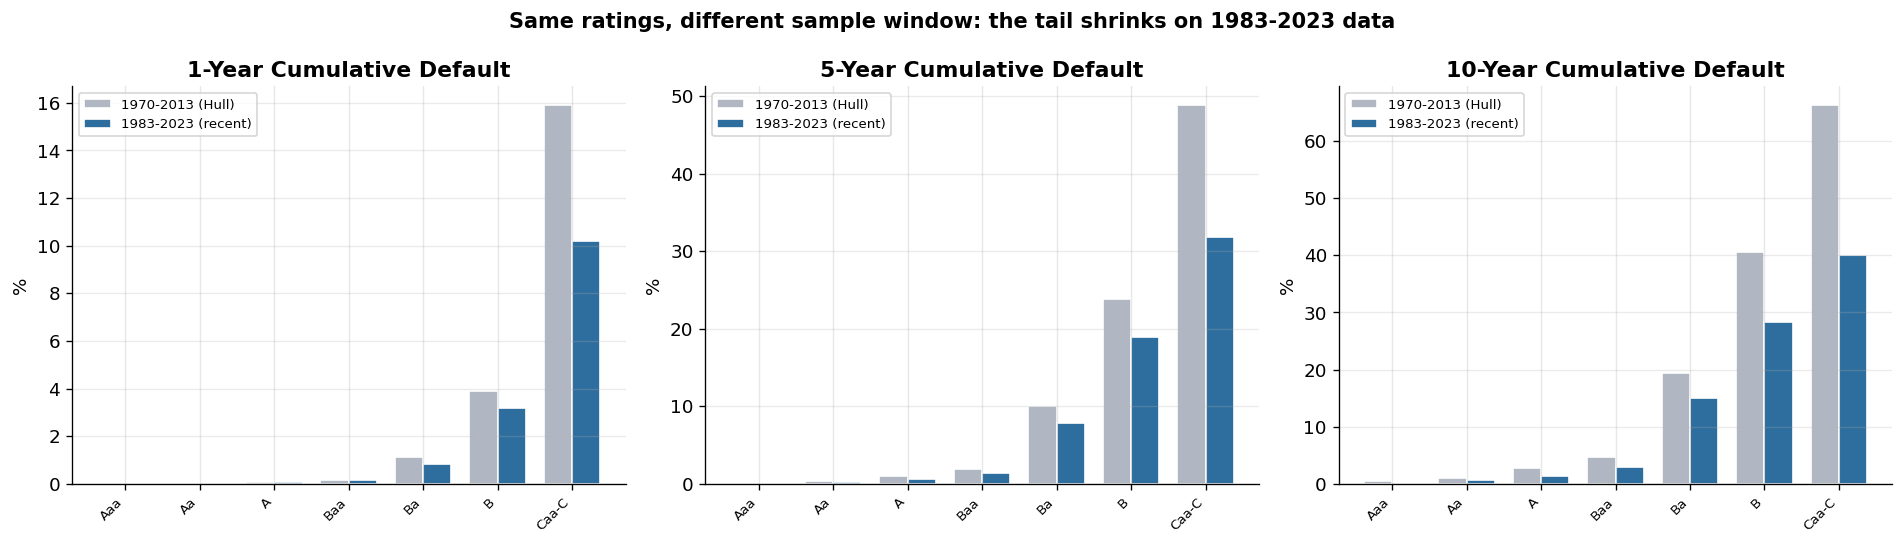


5-year B default:     23.9% (1970-2013)  vs  19.0% (1983-2023)
5-year Caa-C default: 48.8% (1970-2013)  vs  31.9% (1983-2023)
Window and issuer-weighting drive the gap, not a change in the credit process.
NOTE: the 1983-2023 figures are widely-reproduced approximations (years 1/2/3/5/10),
      not extracted from the paywalled study PDF -- verify before graded use.


In [7]:
# -- Window & weighting effect: Moody's 1970-2013 vs 1983-2023 --
cum_old = pd.read_csv(os.path.join(REF_DIR, "moodys_cum_default_1970_2013.csv"), index_col=0)
cum_new = pd.read_csv(os.path.join(REF_DIR, "moodys_cum_default_1983_2023.csv"), index_col=0)

horizons = ["1", "5", "10"]                 # columns present in BOTH tables
ratings  = list(cum_new.index)              # Aaa .. Caa-C

print("Cumulative default rate (%): 1970-2013 (Hull)  vs  1983-2023 (recent)")
print(f"{'Rating':8s}" + "".join(f"| {h+'y old':>8s} {h+'y new':>8s} " for h in horizons))
print("-" * 70)
for r in ratings:
    row = f"{r:8s}"
    for h in horizons:
        row += f"| {cum_old.loc[r, h]:8.2f} {cum_new.loc[r, h]:8.2f} "
    print(row)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, h in zip(axes, horizons):
    x = np.arange(len(ratings)); w = 0.38
    ax.bar(x - w/2, cum_old[h].values, w, color="#B0B7C3", edgecolor="white", label="1970-2013 (Hull)")
    ax.bar(x + w/2, cum_new[h].values, w, color="#2E6E9E", edgecolor="white", label="1983-2023 (recent)")
    ax.set_title(f"{h}-Year Cumulative Default", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(ratings, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("%"); ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")
plt.suptitle("Same ratings, different sample window: the tail shrinks on 1983-2023 data",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

b_old, b_new = cum_old.loc["B", "5"], cum_new.loc["B", "5"]
c_old, c_new = cum_old.loc["Caa-C", "5"], cum_new.loc["Caa-C", "5"]
print(f"\n5-year B default:     {b_old:.1f}% (1970-2013)  vs  {b_new:.1f}% (1983-2023)")
print(f"5-year Caa-C default: {c_old:.1f}% (1970-2013)  vs  {c_new:.1f}% (1983-2023)")
print("Window and issuer-weighting drive the gap, not a change in the credit process.")
print("NOTE: the 1983-2023 figures are widely-reproduced approximations (years 1/2/3/5/10),")
print("      not extracted from the paywalled study PDF -- verify before graded use.")

### Reading a Transition Matrix: Marginal, Conditional, Cumulative - and Hazard

A one-year transition matrix says more than "how ratings drift" - it is a complete default-probability
machine. Raising it to the power $t$ gives the $t$-year outcomes, and the **default (D) column** of
$M^{t}$ is the cumulative default probability by year $t$:

$$Q_i(t)=\big(M^{t}\big)_{i,\,\text{D}},\qquad S(t)=1-Q(t)$$

From the cumulative curve we read off the same four quantities the profession quotes (Hull, RMFI Ch.19):

- **Unconditional / marginal** PD in year $t$ $=Q(t)-Q(t-1)$ &nbsp;(the D column of $M$ itself is the year-1 marginal)
- **Conditional** PD in year $t$ $=\dfrac{Q(t)-Q(t-1)}{1-Q(t-1)}$ &nbsp;(default in year $t$ *given survival* to $t-1$)
- **Hazard rate** $\lambda_t=-\ln\dfrac{S(t)}{S(t-1)}$ &nbsp;(the continuous default intensity)

*We compute these from the real S&P 1981-2024 matrix below. **Session 6** turns the hazard rate into
the engine of reduced-form models and uses it to price a credit value adjustment (CVA).*

S&P BBB: from the 1-year matrix, via M^t
 year  cumulative%  marginal% conditional%  hazard%
    1        0.148      0.148        0.148    0.149
    2        0.352      0.204        0.204    0.204
    3        0.611      0.258        0.259    0.260
    4        0.925      0.314        0.316    0.317
    5        1.295      0.370        0.374    0.375
    6        1.721      0.426        0.432    0.433
    7        2.202      0.481        0.489    0.490

S&P B: from the 1-year matrix, via M^t
 year  cumulative%  marginal% conditional%  hazard%
    1        3.345      3.345        3.345    3.402
    2        7.929      4.584        4.743    4.859
    3       12.832      4.903        5.326    5.473
    4       17.632      4.799        5.506    5.663
    5       22.149      4.517        5.484    5.640
    6       26.324      4.175        5.362    5.511
    7       30.150      3.827        5.194    5.334

Note: the year-1 marginal equals the matrix's own D-column entry; later years need M^t

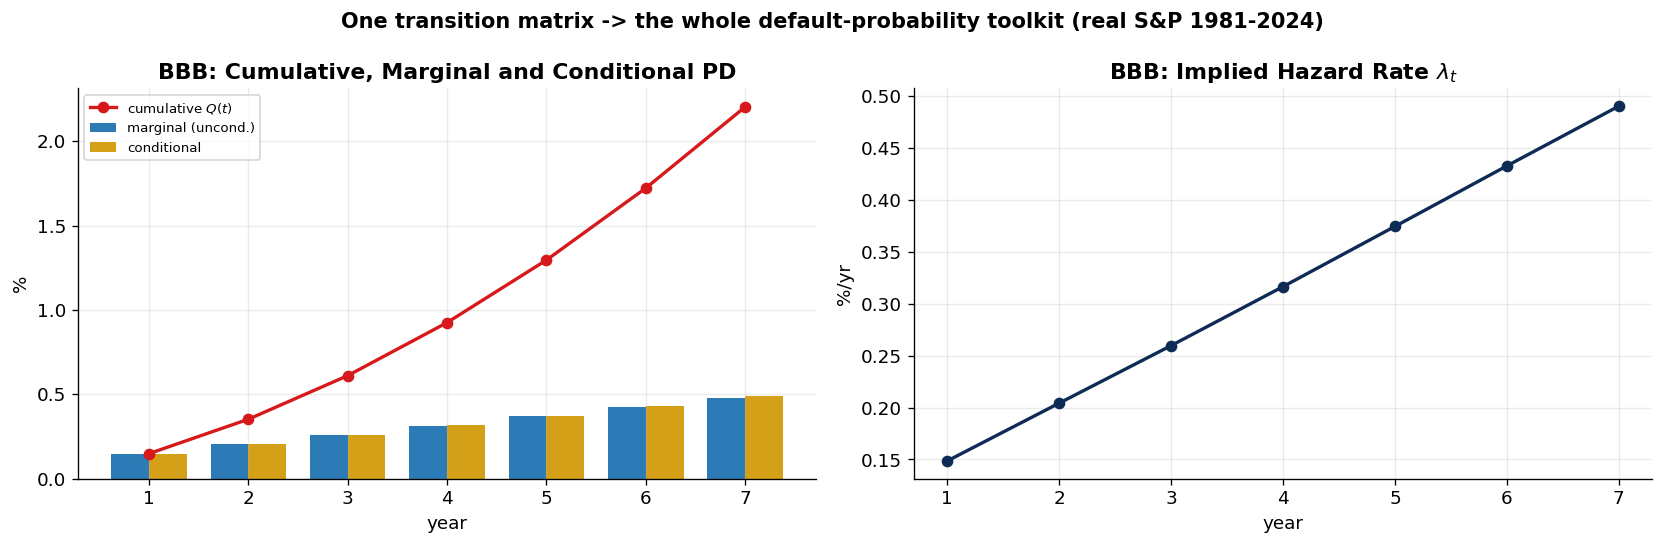

In [8]:
# --- Default-probability toolkit from the REAL S&P transition matrix ---
trm = pd.read_csv(os.path.join(CACHE_DIR, "sp_transition_1981_2024.csv"), index_col=0)
frm = ['AAA','AA','A','BBB','BB','B','CCC/C']        # from-ratings (rows); D has no row (absorbing)
st  = frm + ['D']                                    # to-states we keep (drop NR)
sub = trm.loc[frm, st].values.astype(float)          # 7x8, includes D column, NR dropped
sub = sub / sub.sum(axis=1, keepdims=True)           # renormalise each row (NR removed)
M   = np.zeros((8, 8)); M[:7] = sub; M[7, 7] = 1.0   # add absorbing Default row
Dcol = 7

def toolkit(rating, T=7):
    i = frm.index(rating)
    Q = np.array([0.0] + [np.linalg.matrix_power(M, t)[i, Dcol] for t in range(1, T+1)])
    S = 1 - Q
    return Q[1:], np.diff(Q), np.diff(Q)/S[:-1], -np.log(S[1:]/S[:-1])

for rating in ["BBB","B"]:
    Q, marg, cond, haz = toolkit(rating)
    print(f"S&P {rating}: from the 1-year matrix, via M^t")
    print(f"{'year':>5s}{'cumulative%':>13s}{'marginal%':>11s}{'conditional%':>13s}{'hazard%':>9s}")
    for t in range(len(Q)):
        yr = [1,2,3,4,5,6,7][t]
        print(f"{yr:>5d}{Q[t]*100:>13.3f}{marg[t]*100:>11.3f}{cond[t]*100:>13.3f}{haz[t]*100:>9.3f}")
    print()
print("Note: the year-1 marginal equals the matrix's own D-column entry; later years need M^t.")
print("Marginal is 'from today', conditional is 'given you survived' - they diverge as survival erodes.")

Qb, margb, condb, hazb = toolkit("BBB")
yrs = list(range(1, len(Qb)+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(yrs, Qb*100, 'o-', color=RED, lw=2, label='cumulative $Q(t)$')
axes[0].plot(yrs, np.cumsum(margb)*100, alpha=0)   # keep scale
w=0.38
axes[0].bar([y-w/2 for y in yrs], margb*100, w, color=BLUE, label='marginal (uncond.)')
axes[0].bar([y+w/2 for y in yrs], condb*100, w, color=GOLD, label='conditional')
axes[0].set_title('BBB: Cumulative, Marginal and Conditional PD', fontweight='bold')
axes[0].set_xlabel('year'); axes[0].set_ylabel('%'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
axes[1].plot(yrs, hazb*100, 'o-', color=NAVY, lw=2)
axes[1].set_title('BBB: Implied Hazard Rate $\\lambda_t$', fontweight='bold')
axes[1].set_xlabel('year'); axes[1].set_ylabel('%/yr'); axes[1].grid(alpha=0.25)
plt.suptitle('One transition matrix -> the whole default-probability toolkit (real S&P 1981-2024)',
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()

## Part 3 — The Merton (1974) Structural Model

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">Core insight</div>
<div style="color:#B8D4E8;line-height:1.7;">
At maturity <em>T</em>, shareholders receive <strong>max(V − D, 0)</strong> — they keep the upside and walk away if asset value falls below face value of debt. This is identical to the payoff of a <em>call option</em> on the firm's assets. Using Black-Scholes pricing, we can value equity as:
<br><br>
<strong>E = V·N(d₁) − D·e<sup>−rT</sup>·N(d₂)</strong>
<br><br>
Combined with the equity-volatility linkage σ<sub>E</sub>·E = N(d₁)·σ<sub>V</sub>·V, we have two equations in two unknowns (V, σ<sub>V</sub>) which we solve numerically via <code>scipy.optimize.fsolve</code>.
</div>
</div>

**The two-equation system:**

$$\begin{cases}
E = V \cdot N(d_1) - D \cdot e^{-rT} \cdot N(d_2) & \text{(equity pricing)} \\
\sigma_E \cdot E = N(d_1) \cdot \sigma_V \cdot V & \text{(equity vol linkage)}
\end{cases}$$

where: $d_1 = \dfrac{\ln(V/D) + (r + \tfrac{1}{2}\sigma_V^2)T}{\sigma_V\sqrt{T}}$, $\quad d_2 = d_1 - \sigma_V\sqrt{T}$

**After solving for V and σ_V:**

$$\text{DD} = \frac{\ln(V/D) + (\mu - \tfrac{1}{2}\sigma_V^2)T}{\sigma_V\sqrt{T}}, \qquad \text{PD} = N(-\text{DD})$$

$$\text{Credit spread} = -\frac{1}{T}\ln(1 - \text{PD} \cdot \text{LGD}), \qquad \text{EL} = \text{PD} \cdot \text{LGD} \cdot \text{EAD}$$

In [9]:
# ── Merton model — core functions ─────────────────────────────────────────────
# Note: we reuse bs_call_value and bs_call_delta from black_scholes.py
# which implements: call_value(S, K, T, r, sigma) and call_delta(S, K, T, r, sigma)

def merton_equations(params, E_obs, sigma_E_obs, D, r, T):
    """Two-equation system for [V, sigma_V]. Returns residuals."""
    V, sigma_V = params
    if V <= 0 or sigma_V <= 0:
        return [1e10, 1e10]
    # Equation 1: E = BS_call(V, D, T, r, sigma_V)
    E_model = bs_call_value(V, D, T, r, sigma_V)
    # Equation 2: sigma_E * E = N(d1) * sigma_V * V
    delta   = bs_call_delta(V, D, T, r, sigma_V)  # = N(d1)
    return [E_model - E_obs,
            delta * sigma_V * V - sigma_E_obs * E_obs]


def merton_calibrate(E_obs, sigma_E_obs, D, r=0.04, T=1.0):
    """
    Solve for (V, sigma_V) and compute DD, PD, credit spread, EL.

    Parameters
    ----------
    E_obs      : float  — observed equity market value ($)
    sigma_E_obs: float  — annualised equity volatility
    D          : float  — face value of debt ($)
    r          : float  — risk-free rate (annual)
    T          : float  — time horizon in years (default 1)

    Returns
    -------
    dict with V, sigma_V, d1, d2, DD, PD_rn, spread_bps, EL
    """
    # Initial guess: V ≈ E + D, sigma_V ≈ sigma_E * E / (E + D)
    V0 = E_obs + D
    sv0 = max(sigma_E_obs * E_obs / V0, 0.01)
    try:
        sol = optimize.fsolve(
            merton_equations, [V0, sv0],
            args=(E_obs, sigma_E_obs, D, r, T),
            full_output=True, xtol=1e-10
        )
        V_sol, sigma_V_sol = sol[0]
        if V_sol <= 0 or sigma_V_sol <= 0:
            raise ValueError("Non-positive solution")
    except Exception:
        V_sol, sigma_V_sol = V0, sv0

    # Compute d1, d2 (use r = drift proxy)
    d1 = (np.log(V_sol/D) + (r + 0.5*sigma_V_sol**2)*T) / (sigma_V_sol*np.sqrt(T))
    d2 = d1 - sigma_V_sol * np.sqrt(T)

    # Distance to default (using r as proxy for μ)
    DD   = d2
    PD   = norm.cdf(-DD)           # risk-neutral PD
    LGD  = 0.45

    # Credit spread: s = -(1/T)*ln(1 - PD*LGD)
    arg  = max(1 - PD * LGD, 1e-9)
    spread_bps = -np.log(arg) / T * 10_000

    # Expected loss (per $1 of debt EAD)
    EL   = PD * LGD

    return {
        'V': V_sol, 'sigma_V': sigma_V_sol,
        'd1': d1, 'd2': d2, 'DD': DD,
        'PD_rn': PD, 'LGD': LGD,
        'spread_bps': spread_bps, 'EL': EL,
    }

print("Merton model functions defined.")
print("  merton_equations() — residuals for fsolve")
print("  merton_calibrate() — full calibration → DD, PD, spread, EL")

Merton model functions defined.
  merton_equations() — residuals for fsolve
  merton_calibrate() — full calibration → DD, PD, spread, EL


## Part 4 — Merton Calibration on Real Firm Data

We now apply the model to four firms chosen to span the credit spectrum: MSFT (a solid, low-leverage firm) and three distressed, high-leverage or high-volatility names (LUMN, AMC, BYND). Each uses its market capitalisation, total debt, and equity volatility from five years of price history, so we can see how leverage and volatility push the probability of default up.

In [10]:
results = []
T_horizon = 1.0  # 1-year horizon

for ticker in TICKERS:
    d = firm_data[ticker]
    res = merton_calibrate(
        E_obs       = d['E'],
        sigma_E_obs = d['sigma_E'],
        D           = d['D'],
        r           = RF_ANNUAL,
        T           = T_horizon,
    )
    leverage = d['D'] / res['V'] * 100
    results.append({
        'Ticker':          ticker,
        'Equity ($B)':     d['E'] / 1e9,
        'Debt ($B)':       d['D'] / 1e9,
        'Asset Value ($B)':res['V'] / 1e9,
        'σ_E (%)':         d['sigma_E'] * 100,
        'σ_V (%)':         res['sigma_V'] * 100,
        'DD':              res['DD'],
        'PD (%)':          res['PD_rn'] * 100,
        'Spread (bps)':    res['spread_bps'],
        'EL (%)':          res['EL'] * 100,
        'Leverage (%)':    leverage,
    })

df_results = pd.DataFrame(results).set_index('Ticker')

print("Merton Model Calibration Results")
print("=" * 95)
print(df_results[['Equity ($B)', 'Debt ($B)', 'Asset Value ($B)',
                   'σ_E (%)', 'σ_V (%)', 'DD', 'PD (%)',
                   'Spread (bps)', 'EL (%)', 'Leverage (%)']].round(3).to_string())

Merton Model Calibration Results
        Equity ($B)  Debt ($B)  Asset Value ($B)  σ_E (%)  σ_V (%)      DD  PD (%)  Spread (bps)  EL (%)  Leverage (%)
Ticker                                                                                                                
MSFT        2900.00      40.30          2938.720   27.059   26.703  16.080   0.000        -0.000   0.000         1.371
LUMN           6.65      31.50            36.585   80.262   16.337   1.079  14.024       651.887   6.311        86.100
AMC            1.14       4.02             4.846  101.886   29.152   0.632  26.358      1262.557  11.861        82.958
BYND           0.32       0.41             0.690  109.029   56.224   0.716  23.708      1128.147  10.668        59.423


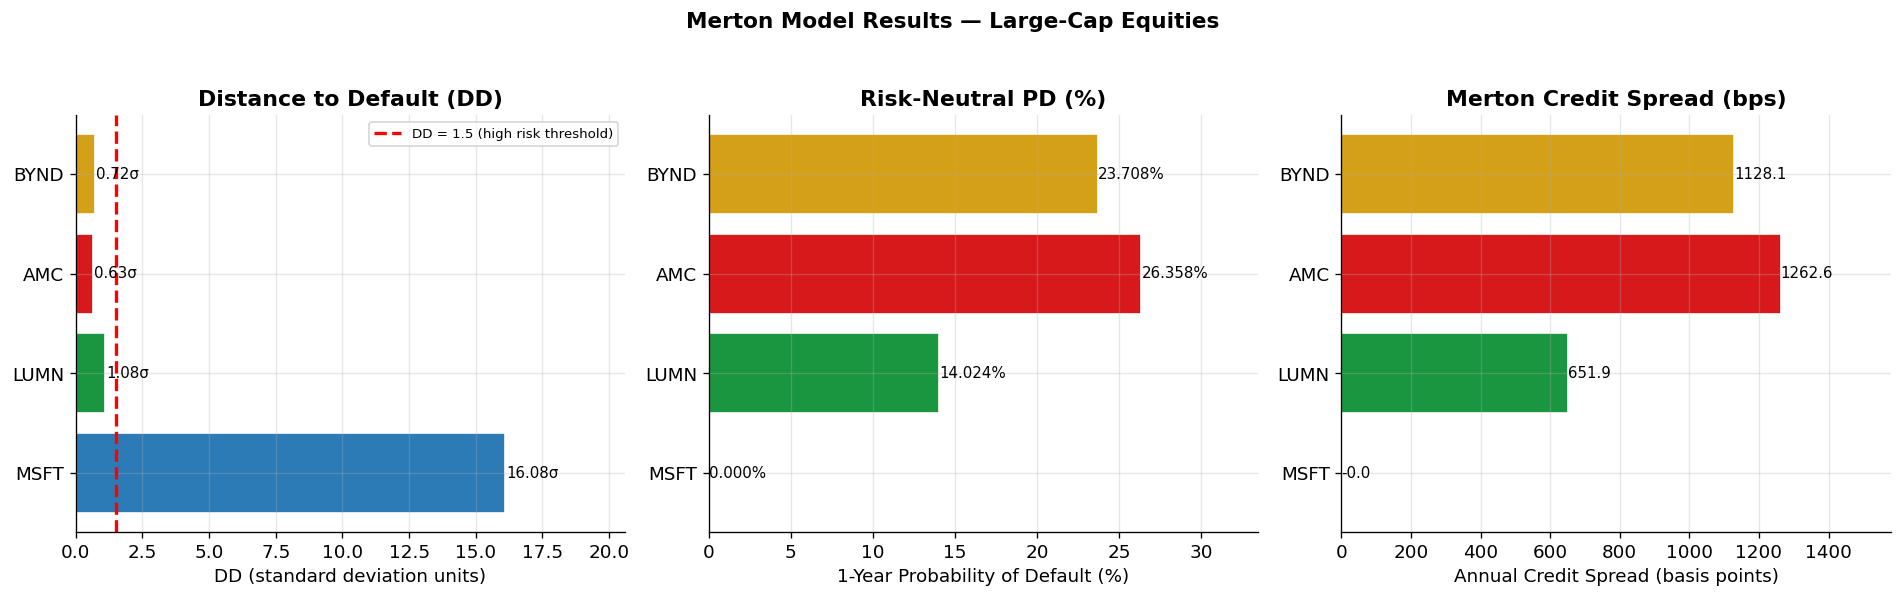

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_f  = [BLUE, GREEN, RED, GOLD]
tickers_  = list(df_results.index)

# ── Distance to Default ───────────────────────────────────────────────────────
DDs = df_results['DD'].values
bars0 = axes[0].barh(tickers_, DDs, color=colors_f, edgecolor='white')
axes[0].axvline(1.5, color='red', ls='--', lw=2, label='DD = 1.5 (high risk threshold)')
axes[0].set_title('Distance to Default (DD)', fontweight='bold')
axes[0].set_xlabel('DD (standard deviation units)')
axes[0].legend(fontsize=8)
for bar, v in zip(bars0, DDs):
    axes[0].text(max(v + 0.05, 0.05), bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}σ', va='center', fontsize=9)

# ── Risk-neutral PD ───────────────────────────────────────────────────────────
PDs = df_results['PD (%)'].values
bars1 = axes[1].barh(tickers_, PDs, color=colors_f, edgecolor='white')
axes[1].set_title('Risk-Neutral PD (%)', fontweight='bold')
axes[1].set_xlabel('1-Year Probability of Default (%)')
for bar, v in zip(bars1, PDs):
    axes[1].text(max(v + 0.002, 0.002), bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}%', va='center', fontsize=9)

# ── Credit spread ─────────────────────────────────────────────────────────────
spreads = df_results['Spread (bps)'].values
bars2 = axes[2].barh(tickers_, spreads, color=colors_f, edgecolor='white')
axes[2].set_title('Merton Credit Spread (bps)', fontweight='bold')
axes[2].set_xlabel('Annual Credit Spread (basis points)')
for bar, v in zip(bars2, spreads):
    axes[2].text(max(v + 0.1, 0.1), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=9)

# Guard against degenerate (all-~0) axes so layout cannot blow up the figure
for _ax, _arr in zip(axes, [DDs, PDs, spreads]):
    _hi = float(np.nanmax(_arr)) if len(_arr) else 1.0
    if (not np.isfinite(_hi)) or _hi <= 0:
        _hi = 1.0
    _ax.set_xlim(0, _hi * 1.25 + 0.5)

plt.suptitle('Merton Model Results — Large-Cap Equities',
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Part 5 — Sensitivity Analysis: PD vs Leverage & Asset Volatility

The Merton model says PD is driven by two forces:
1. **Leverage** — higher D/V means the firm is closer to default
2. **Asset volatility σ_V** — more volatile assets create more chance of breaching the debt threshold

<div style="border-left:5px solid #D7191C;background:#1C0505;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#D7191C;font-weight:700;margin-bottom:7px;">Key insight: Two levers of default risk</div>
<div style="color:#FAB8B3;line-height:1.7;">A firm can have <em>low leverage but high volatility</em> (e.g. a small tech company) and still have a meaningful PD. Conversely, a firm with high leverage but stable cash flows (e.g. a utility) may have a lower PD than naive metrics suggest. The Merton model captures both dimensions simultaneously.</div>
</div>

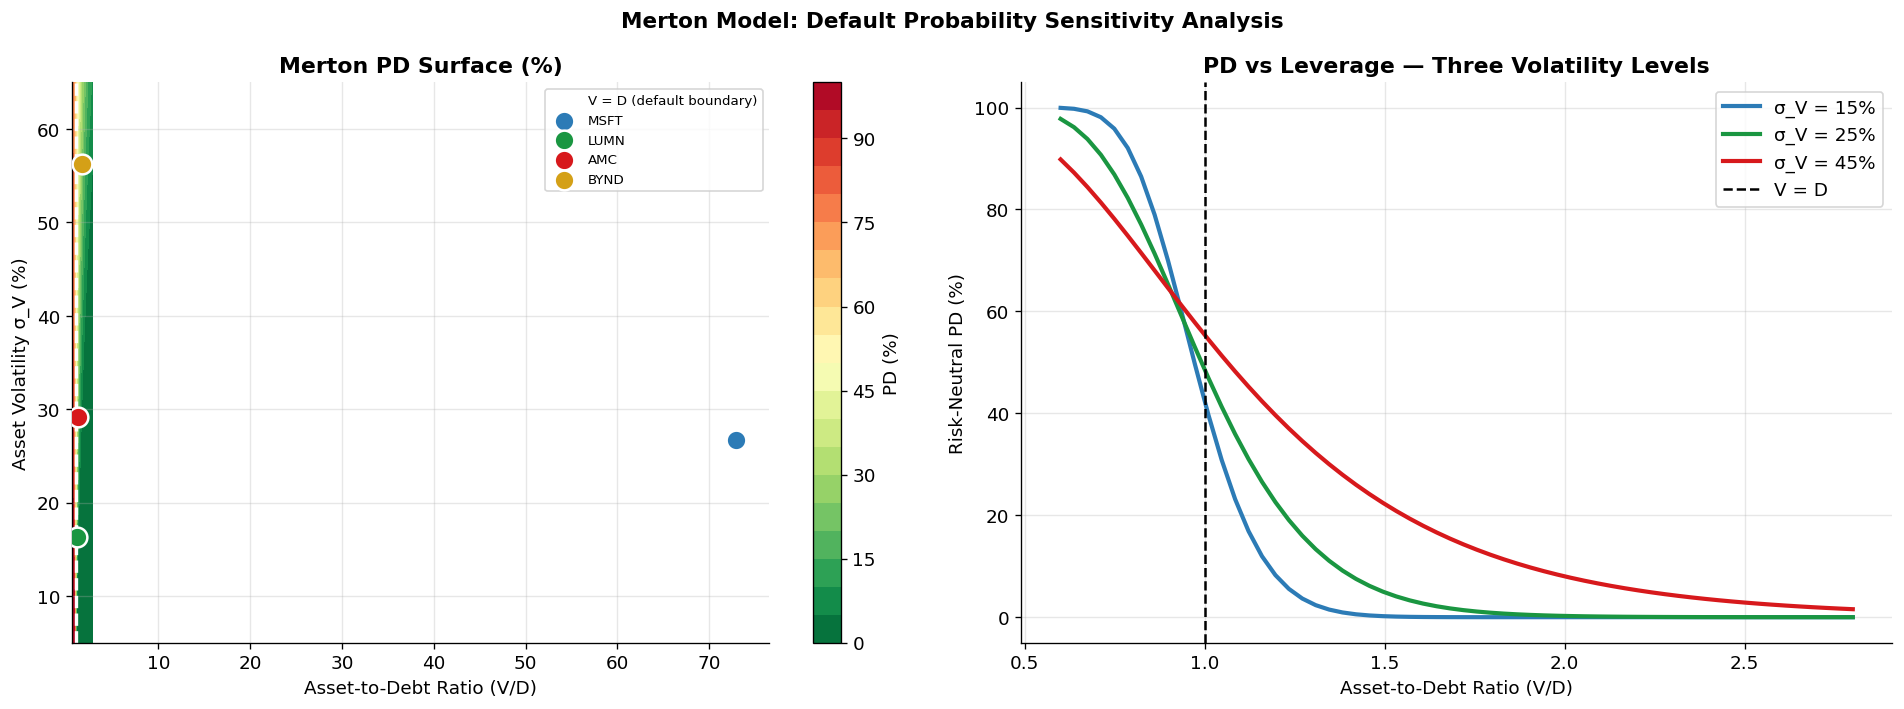

Key takeaway:
  High-leverage firms are vulnerable even at low volatility.
  High-volatility firms with moderate leverage can still have substantial PD.


In [12]:
# ── 2D PD surface: vary V/D ratio and asset volatility ────────────────────────
asset_to_debt = np.linspace(0.6, 2.8, 60)   # V/D ratio
asset_vol     = np.linspace(0.05, 0.65, 60)  # σ_V
r_sens, T_sens = 0.04, 1.0

PD_grid = np.zeros((len(asset_vol), len(asset_to_debt)))
for i, sv in enumerate(asset_vol):
    for j, lev in enumerate(asset_to_debt):
        V, D_norm = lev, 1.0
        if sv > 0:
            d2_val = (np.log(V/D_norm) + (r_sens - 0.5*sv**2)*T_sens) / (sv*np.sqrt(T_sens))
            PD_grid[i, j] = norm.cdf(-d2_val) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour heatmap
cf = axes[0].contourf(asset_to_debt, asset_vol * 100, PD_grid,
                      levels=20, cmap='RdYlGn_r')
plt.colorbar(cf, ax=axes[0], label='PD (%)')
axes[0].axvline(1.0, color='white', lw=2, ls='--', label='V = D (default boundary)')
# Overlay our four firms
for ticker, color in zip(TICKERS, colors_f):
    d = firm_data[ticker]
    res = merton_calibrate(d['E'], d['sigma_E'], d['D'], RF_ANNUAL, T_horizon)
    vd  = res['V'] / d['D']
    sv_ = res['sigma_V'] * 100
    axes[0].scatter(vd, sv_, s=140, color=color, edgecolors='white',
                    lw=1.5, zorder=5, label=ticker)
axes[0].set_xlabel('Asset-to-Debt Ratio (V/D)')
axes[0].set_ylabel('Asset Volatility σ_V (%)')
axes[0].set_title('Merton PD Surface (%)', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

# PD vs leverage slices for three volatility levels
for sv_val, col, lbl in [(0.15, BLUE, 'σ_V = 15%'),
                          (0.25, GREEN, 'σ_V = 25%'),
                          (0.45, RED,   'σ_V = 45%')]:
    pds_ = []
    for lev in asset_to_debt:
        if sv_val > 0:
            d2_ = (np.log(lev) + (r_sens - 0.5*sv_val**2)*T_sens) / (sv_val*np.sqrt(T_sens))
            pds_.append(norm.cdf(-d2_) * 100)
        else:
            pds_.append(0)
    axes[1].plot(asset_to_debt, pds_, color=col, lw=2.5, label=lbl)

axes[1].axvline(1.0, color='black', ls='--', lw=1.5, label='V = D')
axes[1].set_xlabel('Asset-to-Debt Ratio (V/D)')
axes[1].set_ylabel('Risk-Neutral PD (%)')
axes[1].set_title('PD vs Leverage — Three Volatility Levels', fontweight='bold')
axes[1].legend()

plt.suptitle('Merton Model: Default Probability Sensitivity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key takeaway:")
print("  High-leverage firms are vulnerable even at low volatility.")
print("  High-volatility firms with moderate leverage can still have substantial PD.")

## Part 6 — Term Structure of Credit Spreads

The Merton model implies a full term structure of credit spreads. For **investment-grade firms** (V >> D), the short-end spread is near zero (default is unlikely near-term) and spreads rise with maturity. For **distressed firms** (V ≈ D), the short-end spread can be very high.

$$s(T) = -\frac{1}{T} \ln\!\left(N(d_2) + \frac{V}{D e^{rT}} N(-d_1)\right)$$

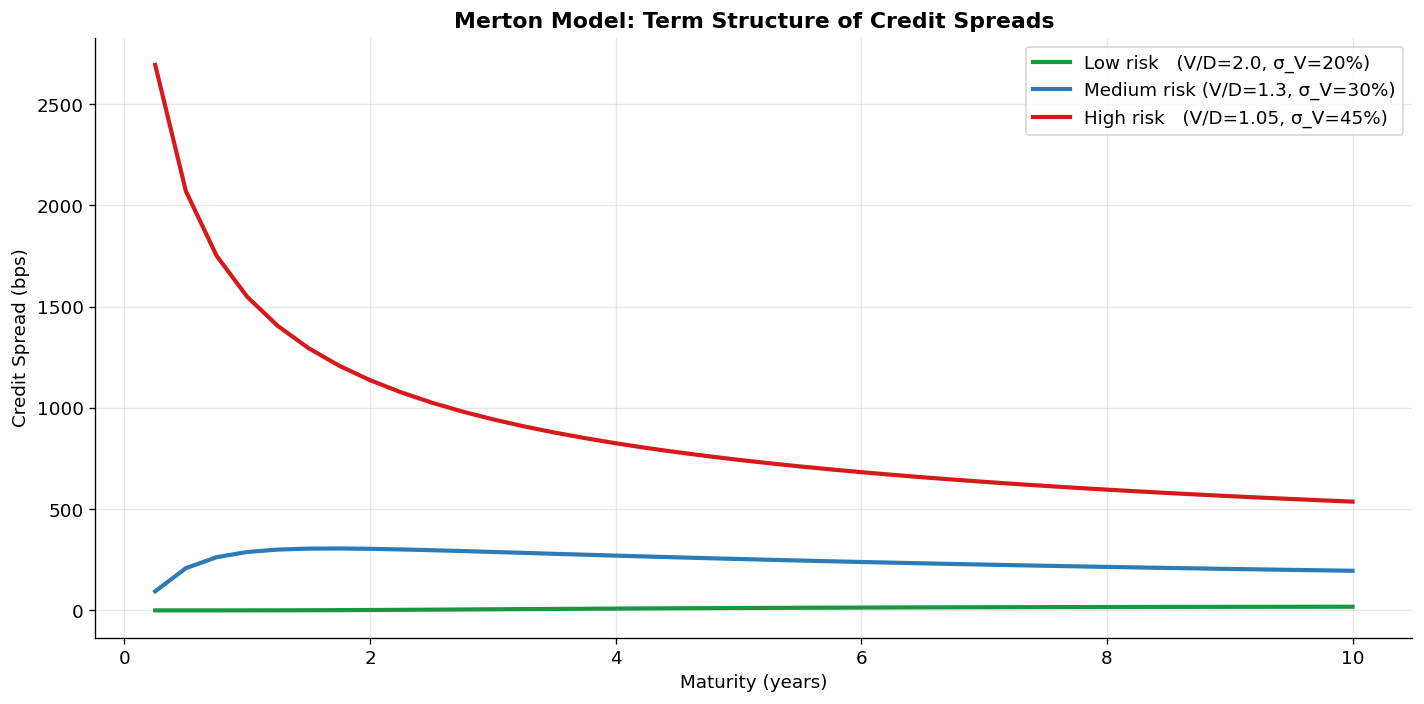

Pattern:
  Investment-grade: upward-sloping spread curve (low near-term risk, rising uncertainty)
  Distressed:       downward-sloping or humped (default imminent in short horizon)


In [13]:
def merton_spread_term(V, D, r, T_mat, sigma_V):
    """Merton credit spread at maturity T_mat (annualised, in bps)."""
    if T_mat <= 0 or sigma_V <= 0 or V <= 0:
        return np.nan
    d1_ = (np.log(V/D) + (r + 0.5*sigma_V**2)*T_mat) / (sigma_V*np.sqrt(T_mat))
    d2_ = d1_ - sigma_V * np.sqrt(T_mat)
    L   = D * np.exp(-r * T_mat)   # PV of debt
    bond_val = V * norm.cdf(-d1_) + L * norm.cdf(d2_)
    if bond_val <= 0 or L <= 0:
        return np.nan
    return -np.log(bond_val / L) / T_mat * 10_000

maturities = np.arange(0.25, 10.25, 0.25)

# Three risk profiles (normalised: D = $1)
profiles = [
    (2.0, 0.20, GREEN, 'Low risk   (V/D=2.0, σ_V=20%)'),
    (1.3, 0.30, BLUE,  'Medium risk (V/D=1.3, σ_V=30%)'),
    (1.05,0.45, RED,   'High risk   (V/D=1.05, σ_V=45%)'),
]

fig, ax = plt.subplots(figsize=(12, 6))
for (vd, sv, col, lbl) in profiles:
    s_curve = [merton_spread_term(vd, 1.0, RF_ANNUAL, T, sv) for T in maturities]
    ax.plot(maturities, s_curve, color=col, lw=2.5, label=lbl)

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Credit Spread (bps)')
ax.set_title('Merton Model: Term Structure of Credit Spreads', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Pattern:")
print("  Investment-grade: upward-sloping spread curve (low near-term risk, rising uncertainty)")
print("  Distressed:       downward-sloping or humped (default imminent in short horizon)")

## Part 7 — Expected Loss Framework

The **Expected Loss (EL)** is the canonical decomposition used across Basel III, IFRS 9, and internal credit models:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

<div style="border-left:5px solid #1A9641;background:#0A1F10;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#52C97A;font-weight:700;margin-bottom:7px;">Three components</div>
<div style="color:#A8D8B0;line-height:1.7;">
<strong>PD</strong> — Probability of Default (from Merton or historical data)<br>
<strong>LGD</strong> — Loss Given Default (typically 40–60% for senior unsecured; higher for subordinated)<br>
<strong>EAD</strong> — Exposure at Default (drawn amount + commitments; equal to outstanding debt here)
</div>
</div>

Expected Loss = PD × LGD × EAD  (EAD = total debt)

MSFT  (PD = 0.0000%,  Debt = $40.3B)
  Senior secured (LGD=30%)           : EL = $    0.00M  (0.0000% of debt)
  Senior unsecured (LGD=45%)         : EL = $    0.00M  (0.0000% of debt)
  Subordinated (LGD=65%)             : EL = $    0.00M  (0.0000% of debt)

LUMN  (PD = 14.0243%,  Debt = $31.5B)
  Senior secured (LGD=30%)           : EL = $ 1325.30M  (4.2073% of debt)
  Senior unsecured (LGD=45%)         : EL = $ 1987.94M  (6.3109% of debt)
  Subordinated (LGD=65%)             : EL = $ 2871.47M  (9.1158% of debt)

AMC  (PD = 26.3579%,  Debt = $4.0B)
  Senior secured (LGD=30%)           : EL = $  317.88M  (7.9074% of debt)
  Senior unsecured (LGD=45%)         : EL = $  476.81M  (11.8611% of debt)
  Subordinated (LGD=65%)             : EL = $  688.73M  (17.1326% of debt)

BYND  (PD = 23.7075%,  Debt = $0.4B)
  Senior secured (LGD=30%)           : EL = $   29.16M  (7.1123% of debt)
  Senior unsecured (LGD=45%)         : EL = $   43.74M 

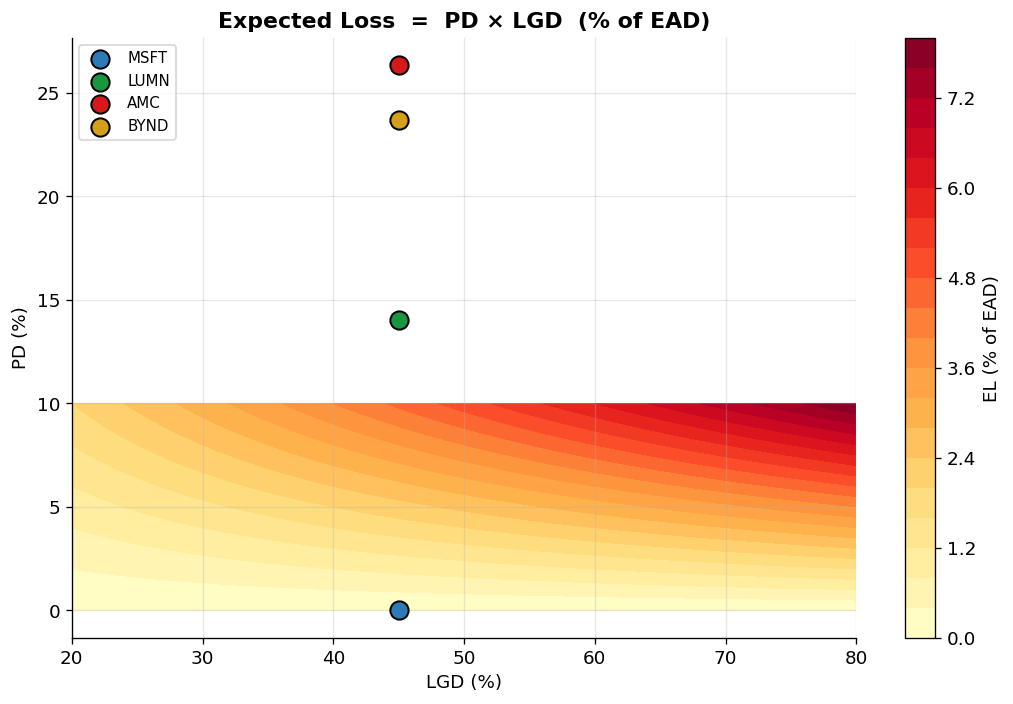

In [14]:
# ── EL for our four firms ──────────────────────────────────────────────────────
lgd_scenarios = {'Senior secured (LGD=30%)': 0.30,
                 'Senior unsecured (LGD=45%)': 0.45,
                 'Subordinated (LGD=65%)': 0.65}

print("Expected Loss = PD × LGD × EAD  (EAD = total debt)")
print("=" * 75)

for ticker in TICKERS:
    d   = firm_data[ticker]
    res = merton_calibrate(d['E'], d['sigma_E'], d['D'], RF_ANNUAL, T_horizon)
    pd_ = res['PD_rn']
    ead = d['D']
    print(f"\n{ticker}  (PD = {pd_*100:.4f}%,  Debt = ${ead/1e9:.1f}B)")
    for lbl, lgd in lgd_scenarios.items():
        el_m = pd_ * lgd * ead / 1e6
        print(f"  {lbl:35s}: EL = ${el_m:8.2f}M  ({pd_*lgd*100:.4f}% of debt)")

# ── EL sensitivity: PD × LGD heatmap ─────────────────────────────────────────
pd_range  = np.linspace(0.0001, 0.10, 50)
lgd_range = np.linspace(0.20, 0.80, 50)
EL_heat   = np.outer(pd_range, lgd_range) * 100  # as % of EAD

fig, ax = plt.subplots(figsize=(9, 6))
cf2 = ax.contourf(lgd_range * 100, pd_range * 100, EL_heat,
                  levels=20, cmap='YlOrRd')
plt.colorbar(cf2, ax=ax, label='EL (% of EAD)')
ax.set_xlabel('LGD (%)')
ax.set_ylabel('PD (%)')
ax.set_title('Expected Loss  =  PD × LGD  (% of EAD)', fontweight='bold')

# Overlay our firms
for ticker, color in zip(TICKERS, colors_f):
    d   = firm_data[ticker]
    res = merton_calibrate(d['E'], d['sigma_E'], d['D'], RF_ANNUAL, T_horizon)
    ax.scatter(45, res['PD_rn']*100, s=120, color=color,
               edgecolors='black', lw=1.2, zorder=5, label=ticker)

ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## Part 8 — Rating-Implied vs Merton-Implied PD Comparison

How do our Merton-derived PDs compare with what credit agencies imply through their ratings?

<div style="border-left:5px solid #D4A017;background:#1C1200;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#D4A017;font-weight:700;margin-bottom:7px;">Structural vs reduced-form perspectives</div>
<div style="color:#F5CBA7;line-height:1.7;">The Merton model gives a <em>real-time, market-implied</em> PD that updates daily as equity prices and balance sheets change. Rating agencies' PDs are longer-run, through-the-cycle estimates. Differences signal either (a) the market is forward-looking about risk the agency hasn't yet recognised, or (b) equity volatility is temporarily elevated (e.g. macro shock) without real credit deterioration.</div>
</div>

Merton-implied PD  vs  Rating-implied PD (real S&P 1981-2024 default frequencies)
Ticker   S&P       Rating PD    Merton PD   Merton spread
--------------------------------------------------------------------------
MSFT     AAA          0.000%      0.0000%         -0.0bp
LUMN     CCC/C       26.120%     14.0243%        651.9bp
AMC      CCC/C       26.120%     26.3579%       1262.6bp
BYND     CCC/C       26.120%     23.7075%       1128.1bp


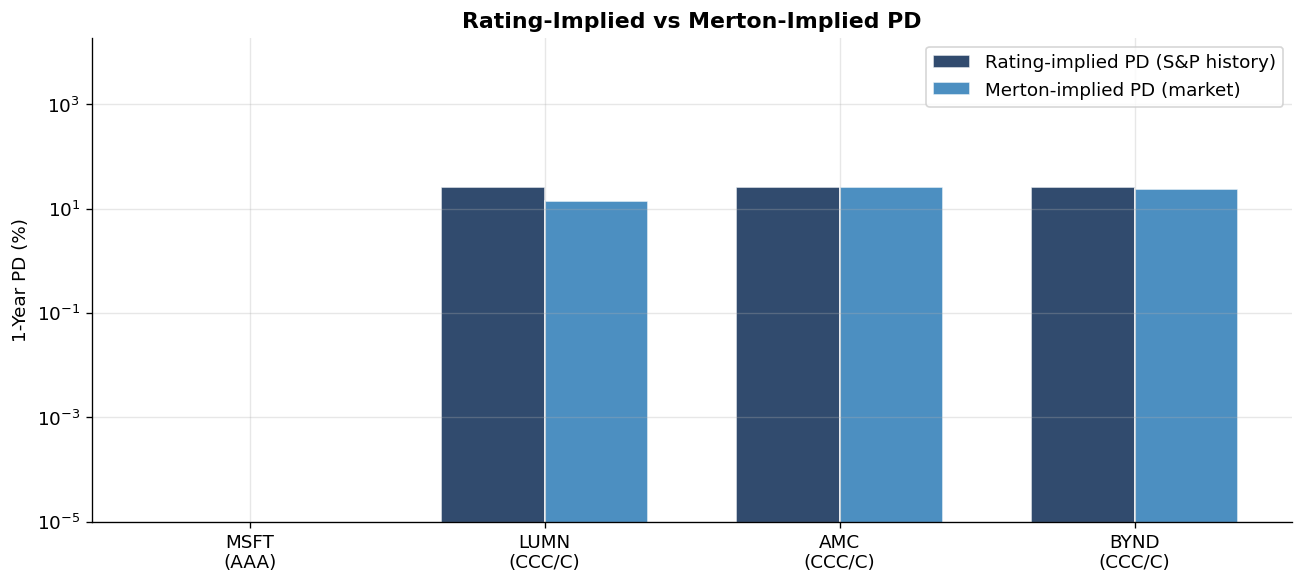


MSFT is safe on both measures. For the distressed names both PDs jump: Merton reacts
fast to market volatility and leverage, while the CCC rating is a slower through-the-cycle anchor.


In [15]:
# ── Rating-implied PD from the REAL S&P transition matrix (D column) ──────────
# The default column of the one-year transition matrix IS the empirical 1-year PD.
sp_default_col = trans["D"]                      # AAA..CCC/C  (%)
rating_to_pd = (sp_default_col / 100).to_dict()  # whole-letter -> 1yr PD

# Approximate whole-letter S&P ratings (2025-2026). The three distressed names sit deep in
# junk (CCC), which is exactly why both the rating and Merton put their PD high; MSFT is the anchor.
firm_ratings = {'MSFT': 'AAA', 'LUMN': 'CCC/C', 'AMC': 'CCC/C', 'BYND': 'CCC/C'}

print("Merton-implied PD  vs  Rating-implied PD (real S&P 1981-2024 default frequencies)")
print("=" * 74)
print(f"{'Ticker':8s} {'S&P':6s} {'Rating PD':>12s} {'Merton PD':>12s} {'Merton spread':>15s}")
print("-" * 74)
comp_rows = []
for ticker in TICKERS:
    d   = firm_data[ticker]
    res = merton_calibrate(d['E'], d['sigma_E'], d['D'], RF_ANNUAL, T_horizon)
    rtg = firm_ratings[ticker]; pd_r = rating_to_pd[rtg]; pd_m = res['PD_rn']
    print(f"{ticker:8s} {rtg:6s} {pd_r*100:>11.3f}% {pd_m*100:>11.4f}% {res['spread_bps']:>12.1f}bp")
    comp_rows.append({'Ticker':ticker,'Rating':rtg,'Rating PD (%)':pd_r*100,
                      'Merton PD (%)':pd_m*100,'Spread (bps)':res['spread_bps']})
comp_df = pd.DataFrame(comp_rows).set_index('Ticker')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TICKERS)); w = 0.35
ax.bar(x-w/2, comp_df['Rating PD (%)'], w, label='Rating-implied PD (S&P history)',
       color=NAVY, alpha=0.85, edgecolor='white')
ax.bar(x+w/2, comp_df['Merton PD (%)'], w, label='Merton-implied PD (market)',
       color=BLUE, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f"{t}\n({firm_ratings[t]})" for t in TICKERS])
ax.set_ylabel('1-Year PD (%)'); ax.set_yscale('log'); ax.set_ylim(bottom=1e-5)
ax.set_title('Rating-Implied vs Merton-Implied PD', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print("\nMSFT is safe on both measures. For the distressed names both PDs jump: Merton reacts")
print("fast to market volatility and leverage, while the CCC rating is a slower through-the-cycle anchor.")

---
## Part 9 — Accounting-Based Default Risk: the Altman Z-Score

Merton needs a traded share price and an option model. **Edward Altman's Z-score (1968)** needs
only five numbers from the financial statements, combined with weights fitted by discriminant
analysis on 66 firms (half of which went bankrupt):

$$Z = 1.2\,X_1 + 1.4\,X_2 + 3.3\,X_3 + 0.6\,X_4 + 1.0\,X_5$$

<div style="border-left:5px solid #1A9641;background:#0A1F10;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#52C97A;font-weight:700;margin-bottom:7px;">The five ratios (all from the 10-K, pulled from SEC EDGAR)</div>
<div style="color:#A8D8B0;line-height:1.7;">
<strong>X<sub>1</sub></strong> = Working Capital / Total Assets &nbsp;(liquidity)<br>
<strong>X<sub>2</sub></strong> = Retained Earnings / Total Assets &nbsp;(cumulative profitability, age)<br>
<strong>X<sub>3</sub></strong> = EBIT / Total Assets &nbsp;(operating productivity)<br>
<strong>X<sub>4</sub></strong> = Market Value of Equity / Total Liabilities &nbsp;(solvency, market cushion)<br>
<strong>X<sub>5</sub></strong> = Sales / Total Assets &nbsp;(asset turnover)<br>
<strong>Zones:</strong> Z &gt; 2.99 safe &nbsp;·&nbsp; 1.81 &lt; Z &lt; 2.99 grey &nbsp;·&nbsp; Z &lt; 1.81 distress.</div>
</div>

The balance-sheet and income-statement inputs below are the **actual figures from each firm's latest
10-K, read straight from SEC EDGAR's XBRL API** (`data.sec.gov/api/xbrl`). We cache them in
`notebook_data/edgar_altman.csv`; set `USE_LIVE_EDGAR = True` to re-pull the latest filings live.
We also compute Altman's later **Z''** (service / non-manufacturer form:
$Z''=6.56X_1+3.26X_2+6.72X_3+1.05X_4'$, with $X_4'$ using *book* equity and dropping sales),
which is more comparable across sectors. Banks (e.g. JPM) are excluded: Altman's model was estimated
on non-financial firms.

Loaded cached EDGAR Altman inputs (edgar_altman.csv).

Altman Z-score on real 10-K data from SEC EDGAR (ordered by credit rating)
       Rating          FY    X1    X2    X3     X4    X5      Z      Zone   Zpp   Zone_pp
Ticker                                                                                   
MSFT      AAA  2025-06-30  0.08  0.38  0.21  10.38  0.46   8.00      Safe  4.49      Safe
AAPL      AA+  2025-09-27 -0.05 -0.04  0.37  16.22  1.16  12.00      Safe  2.31      Grey
XOM       AA-  2025-12-31  0.02  1.07  0.09   3.13  0.62   4.33      Safe  5.79      Safe
WMT        AA  2026-01-31 -0.08  0.37  0.10   5.01  2.48   6.25      Safe  1.97      Grey
F        BBB-  2025-12-31  0.03  0.08 -0.03   0.21  0.65   0.82  Distress  0.38  Distress
AAL        B+  2025-12-31 -0.20 -0.11  0.02   0.17  0.88   0.67  Distress -1.56  Distress


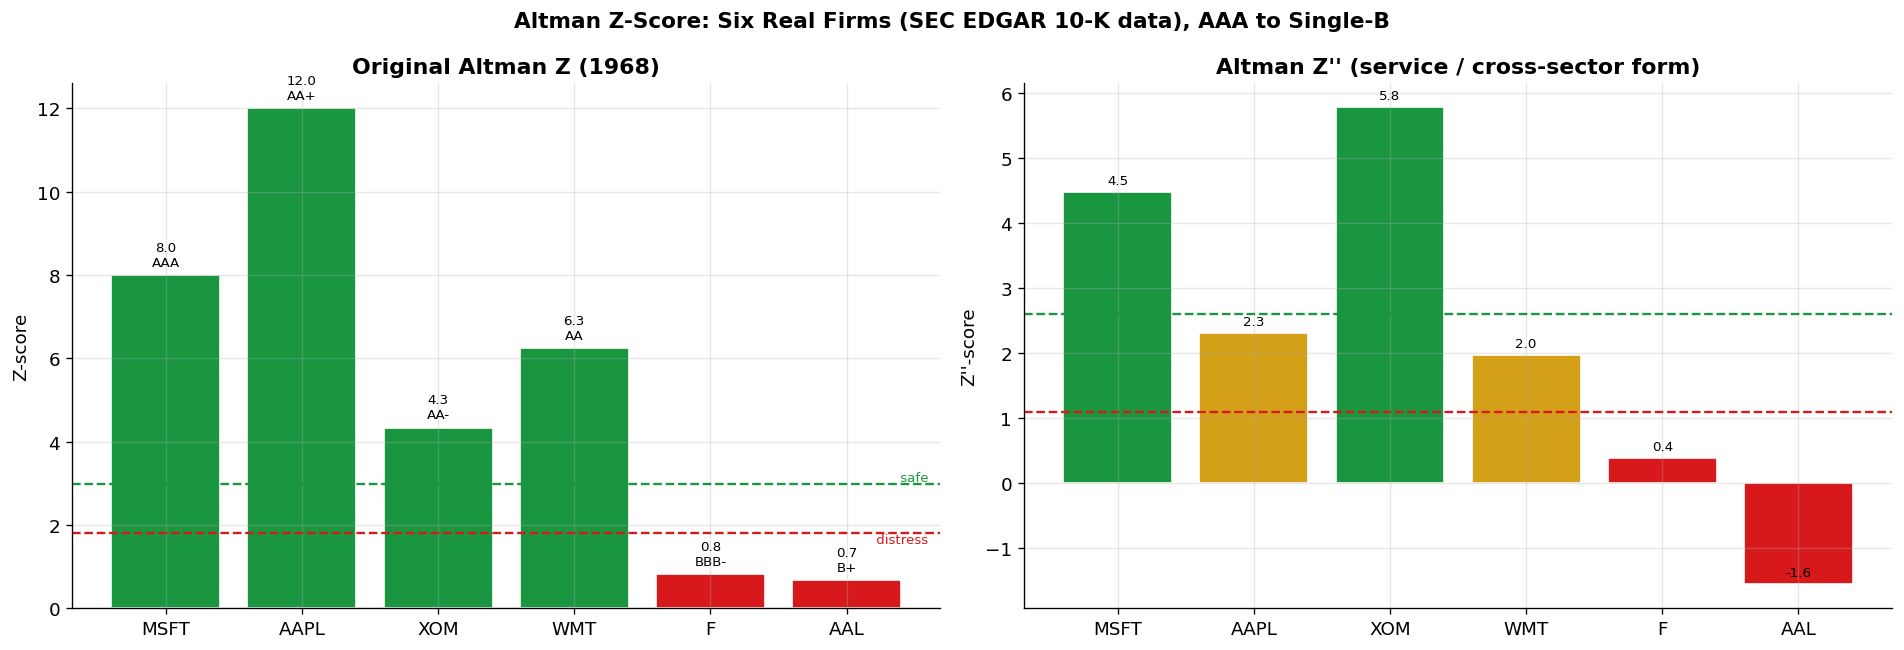


Reading the results:
 - The Z ordering tracks the credit ratings: MSFT/XOM/WMT safe; Ford and American
   Airlines in distress. Ford posted an operating LOSS in its latest 10-K (X3 < 0), so it
   is now flagged distress on BOTH Z and Z'' - the model caught a real deterioration.
 - Apple is the instructive exception: original Z is huge because X4 (a ~$4.6tn market
   cap over its liabilities) dominates, but Z'' drops it to 'grey' - its buyback-driven
   NEGATIVE retained earnings and working capital are a red flag the market term masks.
 - Lesson: accounting scores are cheap and need no market price, but original Z leans on
   market cap; use Z'' to compare across sectors. Data is straight from SEC EDGAR XBRL.


In [16]:
# ── Altman inputs from SEC EDGAR (XBRL companyfacts), latest 10-K per firm ────
import json, urllib.request
from datetime import date

EDGAR_UA = "FRM Course (yuriy.zabolotnyuk@carleton.ca)"   # SEC asks for a contact UA
USE_LIVE_EDGAR = False   # True -> re-pull latest filings live; False -> use cached CSV

CIK    = {'MSFT':789019,'AAPL':320193,'XOM':34088,'WMT':104169,'F':37996,'AAL':6201}
MCAP   = {'MSFT':2860,'AAPL':4630,'XOM':570,'WMT':895,'F':54,'AAL':11}   # $bn, approx Jul 2026
RATING = {'MSFT':'AAA','AAPL':'AA+','XOM':'AA-','WMT':'AA','F':'BBB-','AAL':'B+'}

def _fetch_edgar_altman():
    """Pull Altman inputs from EDGAR companyfacts; latest full-year 10-K values."""
    IN  = {'CA':['AssetsCurrent'],'CL':['LiabilitiesCurrent'],'TA':['Assets'],
           'RE':['RetainedEarningsAccumulatedDeficit'],'TL':['Liabilities'],
           'BookEq':['StockholdersEquity'],
           'EqNCI':['StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest']}
    FLOW= {'Rev':['RevenueFromContractWithCustomerExcludingAssessedTax','Revenues','RevenuesNetOfInterestExpense'],
           'OpInc':['OperatingIncomeLoss']}
    def _d(s): y,m,dd=map(int,s.split('-')); return date(y,m,dd)
    def _get(cik):
        url=f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik:010d}.json"
        req=urllib.request.Request(url, headers={'User-Agent':EDGAR_UA})
        with urllib.request.urlopen(req, timeout=25) as r:
            return json.load(r)['facts']
    def _instant(f,tags):
        for t in tags:
            n=f.get('us-gaap',{}).get(t)
            if not n: continue
            for u,vs in n['units'].items():
                if 'USD' not in u: continue
                tk=[v for v in vs if v.get('form')=='10-K' and 'start' not in v]
                if tk: b=sorted(tk,key=lambda v:v['end'])[-1]; return b['val'],b['end']
        return None,None
    def _flow(f,tags):
        for t in tags:
            n=f.get('us-gaap',{}).get(t)
            if not n: continue
            for u,vs in n['units'].items():
                if 'USD' not in u: continue
                tk=[v for v in vs if v.get('form')=='10-K' and v.get('start')
                    and 350<=(_d(v['end'])-_d(v['start'])).days<=380]
                if tk: b=sorted(tk,key=lambda v:v['end'])[-1]; return b['val'],b['end']
        return None,None
    rows=[]
    for tk,cik in CIK.items():
        f=_get(cik); r={'Ticker':tk}
        for c,tags in INN.items(): r[c],_=_instant(f,tags)
        r['FY']=_instant(f,['Assets'])[1]
        for c,tags in FLOW.items(): r[c],_=_flow(f,tags)
        r['EBIT']=r['OpInc']
        if r['TL'] is None:
            eq=r['EqNCI'] if r['EqNCI'] is not None else r['BookEq']
            r['TL']=r['TA']-eq if (r['TA'] and eq is not None) else None
        r['MCap']=MCAP[tk]; r['Rating']=RATING[tk]
        rows.append(r)
    return pd.DataFrame(rows).set_index('Ticker')

INN = {'CA':['AssetsCurrent'],'CL':['LiabilitiesCurrent'],'TA':['Assets'],
       'RE':['RetainedEarningsAccumulatedDeficit'],'TL':['Liabilities'],
       'BookEq':['StockholdersEquity'],
       'EqNCI':['StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest']}

CACHE_ALT = os.path.join(CACHE_DIR, "edgar_altman.csv")
A = None
if USE_LIVE_EDGAR:
    try:
        A = _fetch_edgar_altman()
        A.reset_index().to_csv(CACHE_ALT, index=False)
        print("Pulled latest 10-K figures live from SEC EDGAR.")
    except Exception as e:
        print(f"EDGAR live pull failed ({e}); using cached edgar_altman.csv.")
if A is None:
    A = pd.read_csv(CACHE_ALT).set_index('Ticker')
    print("Loaded cached EDGAR Altman inputs (edgar_altman.csv).")

# Amounts are in USD; convert to $ millions for readability
for c in ['CA','CL','TA','RE','EBIT','Rev','TL','BookEq']:
    A[c] = A[c].astype(float) / 1e6
A = A.loc[list(CIK)]                                  # fixed rating order

A['WC'] = A.CA - A.CL
A['X1'] = A.WC / A.TA
A['X2'] = A.RE / A.TA
A['X3'] = A.EBIT / A.TA
A['X4'] = (A.MCap*1000) / A.TL                        # market equity / total liabilities
A['X5'] = A.Rev / A.TA
A['Z']  = 1.2*A.X1 + 1.4*A.X2 + 3.3*A.X3 + 0.6*A.X4 + 1.0*A.X5
A['X4b']= A.BookEq / A.TL
A['Zpp']= 6.56*A.X1 + 3.26*A.X2 + 6.72*A.X3 + 1.05*A.X4b
zZ  = lambda z:'Safe' if z>2.99 else ('Grey' if z>1.81 else 'Distress')
zZp = lambda z:'Safe' if z>2.60 else ('Grey' if z>1.10 else 'Distress')
A['Zone'], A['Zone_pp'] = A.Z.apply(zZ), A.Zpp.apply(zZp)

print("\nAltman Z-score on real 10-K data from SEC EDGAR (ordered by credit rating)")
print("="*90)
print(A[['Rating','FY','X1','X2','X3','X4','X5','Z','Zone','Zpp','Zone_pp']].round(2).to_string())

zc = {'Safe':GREEN,'Grey':GOLD,'Distress':RED}
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5)); order=list(A.index)
axes[0].bar(order, A.Z.values, color=[zc[z] for z in A.Zone], edgecolor='white')
axes[0].axhline(2.99, color=GREEN, ls='--', lw=1.4); axes[0].axhline(1.81, color=RED, ls='--', lw=1.4)
axes[0].text(len(order)-0.4, 2.99, ' safe', color=GREEN, va='bottom', ha='right', fontsize=8)
axes[0].text(len(order)-0.4, 1.81, ' distress', color=RED, va='top', ha='right', fontsize=8)
axes[0].set_title("Original Altman Z (1968)", fontweight='bold'); axes[0].set_ylabel('Z-score')
for i,t in enumerate(order):
    axes[0].text(i, A.Z[t]+0.15, f'{A.Z[t]:.1f}\n{A.Rating[t]}', ha='center', va='bottom', fontsize=8)
axes[1].bar(order, A.Zpp.values, color=[zc[z] for z in A.Zone_pp], edgecolor='white')
axes[1].axhline(2.60, color=GREEN, ls='--', lw=1.4); axes[1].axhline(1.10, color=RED, ls='--', lw=1.4)
axes[1].set_title("Altman Z'' (service / cross-sector form)", fontweight='bold'); axes[1].set_ylabel("Z''-score")
for i,t in enumerate(order):
    axes[1].text(i, A.Zpp[t]+0.08, f'{A.Zpp[t]:.1f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Altman Z-Score: Six Real Firms (SEC EDGAR 10-K data), AAA to Single-B',
             fontsize=13, fontweight='bold'); plt.tight_layout(); plt.show()

print("\nReading the results:")
print(" - The Z ordering tracks the credit ratings: MSFT/XOM/WMT safe; Ford and American")
print("   Airlines in distress. Ford posted an operating LOSS in its latest 10-K (X3 < 0), so it")
print("   is now flagged distress on BOTH Z and Z'' - the model caught a real deterioration.")
print(" - Apple is the instructive exception: original Z is huge because X4 (a ~$4.6tn market")
print("   cap over its liabilities) dominates, but Z'' drops it to 'grey' - its buyback-driven")
print("   NEGATIVE retained earnings and working capital are a red flag the market term masks.")
print(" - Lesson: accounting scores are cheap and need no market price, but original Z leans on")
print("   market cap; use Z'' to compare across sectors. Data is straight from SEC EDGAR XBRL.")

---
## Part 9 - Fundamental Credit Ratios: the S&P Scorecard

Merton and the market give a *price-based* view of credit. Rating agencies and bank credit
committees start somewhere more old-fashioned: the **financial statements**. Traditional credit
analysis weighs the **Four C's** - Capacity, Collateral, Covenants, Character - and *Capacity to
pay* is made quantitative through a small set of ratios. Standard & Poor's publishes a canonical
panel (its *Adjusted Key U.S. Industrial Financial Ratios*), and it is worth knowing by heart:

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">The S&P key-ratio panel</div>
<div style="color:#B8D4E8;line-height:1.8;">
<strong>Coverage</strong> &nbsp; EBIT interest coverage = EBIT / interest &nbsp;&middot;&nbsp; EBITDA interest coverage = (EBIT + D&amp;A) / interest<br>
<strong>Cash flow / leverage</strong> &nbsp; FFO / total debt &nbsp;&middot;&nbsp; free operating cash flow / total debt &nbsp; (FFO = net income + D&amp;A; FOCF = FFO - capex)<br>
<strong>Profitability</strong> &nbsp; pre-tax return on capital = EBIT / (debt + equity) &nbsp;&middot;&nbsp; operating margin = EBIT / sales<br>
<strong>Leverage</strong> &nbsp; total debt / capitalization
</div></div>

The trick practitioners use: each rating category has a **median** for every ratio. Compute a
firm's ratios, see which rating's medians they most resemble, and compare that to the firm's
*actual* rating. A firm whose ratios sit a notch or two **below** its rating is a **downgrade
candidate** - exactly how an analyst would have flagged Bergen Brunswig a year before S&P cut it
(the case study in Fabozzi Ch.15).

*Data: the same SEC EDGAR 10-K figures used for Altman (`edgar_ratios.csv`), benchmarked against
S&P's published 3-year median ratios (`sp_ratio_medians.csv`). Two EDGAR extraction gaps are filled
with sourced 10-K values (MSFT D&A = depreciation 22.0B + intangible amortization 6.0B; Ford total
debt ~ $159B, dominated by the Ford Credit funding book - itself a teaching point).*

S&P key-ratio scorecard (real latest-10-K data via SEC EDGAR)
Firm    Rtg  EBITcov  EBITDAcov   FFO/D%  FOCF/D%  ptxROC%  OpMgn%  D/Cap%
MSFT    AAA     43.8       53.3    300.9    151.3     33.2    45.6    11.2
AAPL    AA+     33.8       36.8    136.4    122.4     80.9    32.0    55.2
XOM     AA-     69.4      112.5    187.2     90.4     14.5    15.1    10.1
WMT      AA     12.9       17.5     85.3     15.5     21.6     4.2    27.7
F      BBB-     -1.2        0.9     13.8      8.2     -4.7    -4.9    81.5
AAL      B+      0.7        1.7     22.3    -14.1     22.1     2.7   156.1

Ratios-implied rating vs actual rating (positive notches = ratios look WEAKER than rating):
  MSFT   actual  AAA -> ratios imply  AAA  (+0 notches)
  AAPL   actual  AA+ -> ratios imply  AAA  (-1 notches)
  XOM    actual  AA- -> ratios imply  AAA  (-1 notches)
  WMT    actual   AA -> ratios imply  BBB  (+2 notches)  <-- downgrade pressure
  F      actual BBB- -> ratios imply    B  (+2 notches)  <-- downgrade p

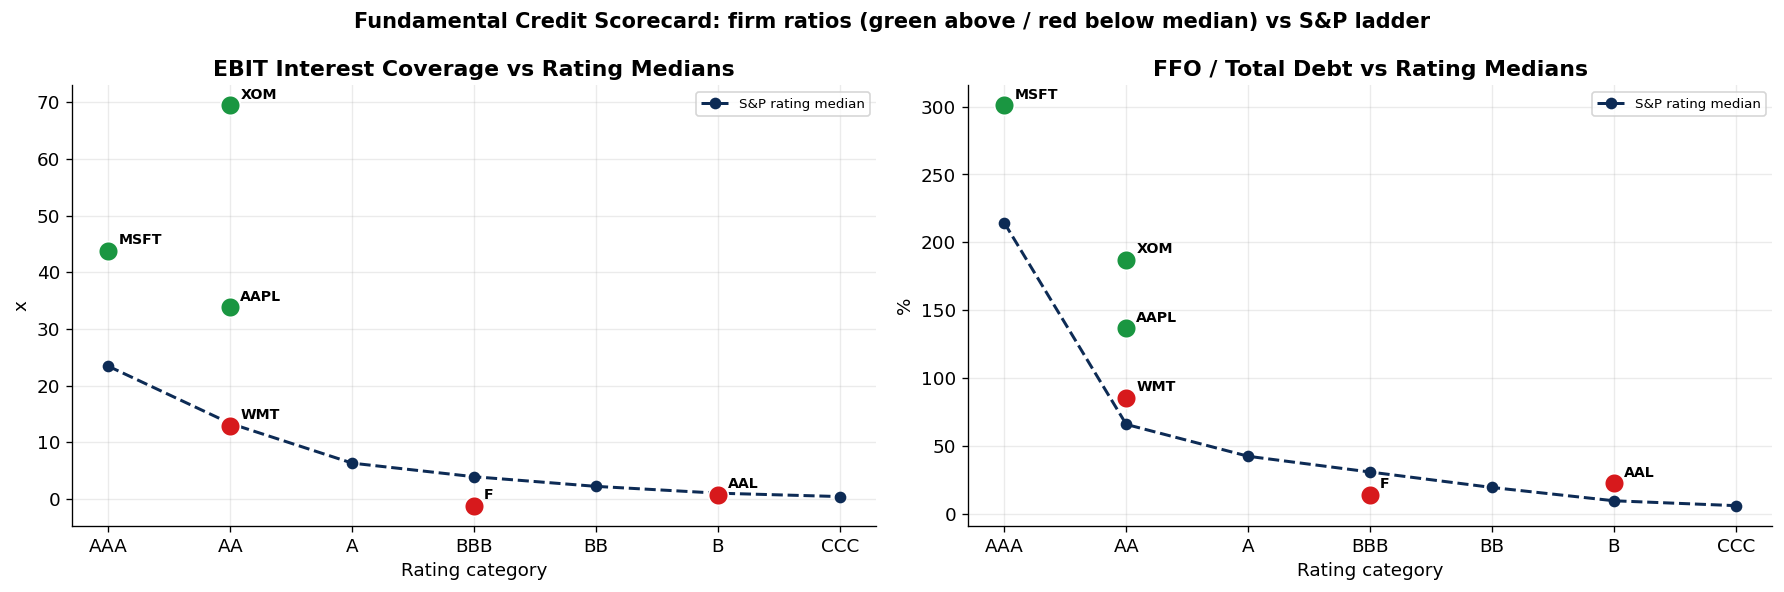


Reading the board: coverage and FFO/debt place each firm on the ladder. Ford posts an
operating LOSS (EBIT coverage < 0, debt/cap 82%) and screens two notches below BBB- - the same
distress its Altman Z flags (a true early warning). Microsoft, Apple and Exxon screen AA-AAA.
Walmart is the cautionary case: its thin ~4% retail operating margin drags it below the *industrial*
median ladder even though it is a genuine AA - the classic 'scoring models over-classify troubled
credits' limitation (Fridson). The ladder is a screen, not a verdict: a real analyst adjusts for
sector (thin-margin retail, asset-heavy utilities) before acting. Fundamental analysis made
quantitative - a fast early-warning system, read with judgement.


In [17]:
# --- S&P key-ratio scorecard on the real 10-K data ---
alt = pd.read_csv(os.path.join(CACHE_DIR, "edgar_altman.csv"))
rat = pd.read_csv(os.path.join(CACHE_DIR, "edgar_ratios.csv"))
med = pd.read_csv(os.path.join(CACHE_DIR, "sp_ratio_medians.csv"))

# EBIT, Rev, BookEq come from the validated Altman pull; the rest from the ratio pull
f = (alt[['Ticker','EBIT','Rev','BookEq','Rating']]
     .merge(rat[['Ticker','DA','Interest','NI','Capex','TotalDebt']], on='Ticker'))
f['EBITDA'] = f['EBIT'] + f['DA']
f['FFO']    = f['NI']  + f['DA']
f['FOCF']   = f['FFO'] - f['Capex']

S = pd.DataFrame({'Ticker': f['Ticker'], 'Rating': f['Rating']})
S['EBIT_cov']    = f['EBIT']   / f['Interest']
S['EBITDA_cov']  = f['EBITDA'] / f['Interest']
S['FFO_debt']    = 100 * f['FFO']  / f['TotalDebt']
S['FOCF_debt']   = 100 * f['FOCF'] / f['TotalDebt']
S['PretaxROC']   = 100 * f['EBIT'] / (f['TotalDebt'] + f['BookEq'])
S['OperMargin']  = 100 * f['EBIT'] / f['Rev']
S['TotDebt_cap'] = 100 * f['TotalDebt'] / (f['TotalDebt'] + f['BookEq'])

RCOLS = ['EBIT_cov','EBITDA_cov','FFO_debt','FOCF_debt','PretaxROC','OperMargin','TotDebt_cap']
order = ['AAA','AA','A','BBB','BB','B','CCC']

print("S&P key-ratio scorecard (real latest-10-K data via SEC EDGAR)")
print(f"{'Firm':6s}{'Rtg':>5s}{'EBITcov':>9s}{'EBITDAcov':>11s}{'FFO/D%':>9s}"
      f"{'FOCF/D%':>9s}{'ptxROC%':>9s}{'OpMgn%':>8s}{'D/Cap%':>8s}")
for _,r in S.iterrows():
    print(f"{r.Ticker:6s}{r.Rating:>5s}{r.EBIT_cov:9.1f}{r.EBITDA_cov:11.1f}{r.FFO_debt:9.1f}"
          f"{r.FOCF_debt:9.1f}{r.PretaxROC:9.1f}{r.OperMargin:8.1f}{r.TotDebt_cap:8.1f}")

# --- Map each firm's ratio profile to the nearest rating category (implied rating) ---
# z-normalise each ratio across the median table, higher-is-better except leverage; then
# score every firm against every rating's median and pick the closest (Euclidean) match.
sign = {c: (-1 if c=='TotDebt_cap' else 1) for c in RCOLS}
scale = {c: med[c].std(ddof=0) for c in RCOLS}
def implied_rating(row):
    best, bestd = None, 1e18
    for _,mrow in med.iterrows():
        d = sum(((sign[c]*(row[c]-mrow[c]))/scale[c])**2 for c in RCOLS)
        if d < bestd: bestd, best = d, mrow['Rating']
    return best
def notch(r):  # distance in notches on the AAA..CCC ladder (+ = ratios imply weaker than rating)
    return order.index(implied_rating(r)) - order.index(broad(r['Rating']))
def broad(r):  # collapse +/- modifiers to the 7 broad buckets used by the median table
    r = r.replace('+','').replace('-','')
    return {'AAA':'AAA','AA':'AA','A':'A','BBB':'BBB','BB':'BB','B':'B','CCC':'CCC'}.get(r,'BBB')
S['Implied'] = S.apply(implied_rating, axis=1)
S['Notches'] = S.apply(notch, axis=1)

print("\nRatios-implied rating vs actual rating (positive notches = ratios look WEAKER than rating):")
for _,r in S.iterrows():
    flag = "  <-- downgrade pressure" if r.Notches >= 2 else ("  (screens strong)" if r.Notches <= -2 else "")
    print(f"  {r.Ticker:6s} actual {r.Rating:>4s} -> ratios imply {r.Implied:>4s}  ({r.Notches:+d} notches){flag}")

# --- Visualise: two headline ratios vs the rating-median ladder ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
def panel(ax, col, title, ylab):
    ax.plot(order, med[col].values, 'o--', color=NAVY, lw=1.8, label='S&P rating median')
    for _,r in S.iterrows():
        b = broad(r['Rating'])
        ax.scatter([b],[r[col]], s=140, color=(GREEN if r.Notches<=0 else RED),
                   edgecolor='white', zorder=5)
        ax.annotate(r.Ticker, (order.index(b), r[col]), xytext=(6,4),
                    textcoords='offset points', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylab); ax.set_xlabel('Rating category')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
panel(axes[0], 'EBIT_cov',  'EBIT Interest Coverage vs Rating Medians', 'x')
panel(axes[1], 'FFO_debt',  'FFO / Total Debt vs Rating Medians', '%')
plt.suptitle('Fundamental Credit Scorecard: firm ratios (green above / red below median) vs S&P ladder',
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()

print("\nReading the board: coverage and FFO/debt place each firm on the ladder. Ford posts an")
print("operating LOSS (EBIT coverage < 0, debt/cap 82%) and screens two notches below BBB- - the same")
print("distress its Altman Z flags (a true early warning). Microsoft, Apple and Exxon screen AA-AAA.")
print("Walmart is the cautionary case: its thin ~4% retail operating margin drags it below the *industrial*")
print("median ladder even though it is a genuine AA - the classic 'scoring models over-classify troubled")
print("credits' limitation (Fridson). The ladder is a screen, not a verdict: a real analyst adjusts for")
print("sector (thin-margin retail, asset-heavy utilities) before acting. Fundamental analysis made")
print("quantitative - a fast early-warning system, read with judgement.")

---
## Part 10 — Data-Driven Default Prediction: A Logistic-Regression PD Scorecard

Merton and ratings give a PD for a *listed* firm with traded equity. But most credit
decisions — a card, a personal loan, an SME facility — involve borrowers with **no share
price at all**. There, the industry standard is a **statistical scorecard**: fit a model
that maps borrower attributes to P(default) directly from historical outcomes.

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">Real data: 30,000 real credit-card borrowers</div>
<div style="color:#B8D4E8;line-height:1.7;">We use the <strong>UCI "Default of Credit Card Clients"</strong> dataset (Yeh &amp; Lien, 2009):
30,000 Taiwanese card holders, their limit, demographics, six months of repayment status
(<code>PAY_0..PAY_6</code>), bills and payments, and whether they <strong>defaulted next month</strong>
(22.1% did). We fit a logistic regression
$\;P(\text{default}) = \sigma(\beta_0 + \sum \beta_i x_i)\;$ and evaluate it out-of-sample
with the <strong>ROC / AUC</strong> — the discrimination metric every bank validation team reports.</div>
</div>

Borrowers: 30,000 | overall default rate: 22.1%
Out-of-sample AUC = 0.712   (0.5 = coin flip, 1.0 = perfect)


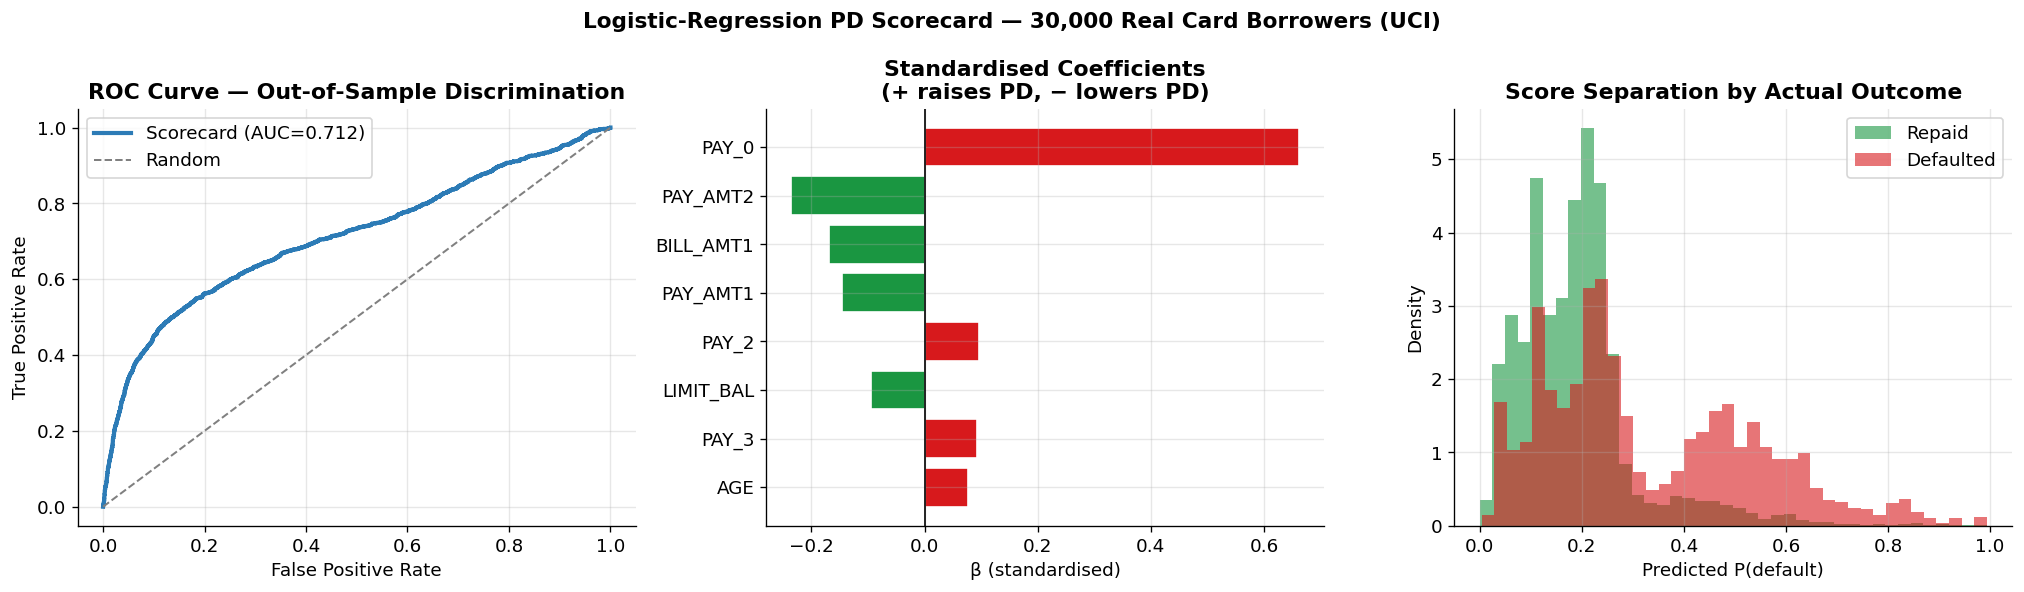


Most powerful predictor: PAY_0 (recent repayment status) — being 1-2 months late last month dominates every
demographic. This is exactly what real behavioural scorecards find: recent
delinquency, not income or age, is the sharpest signal of near-term default.


In [18]:
import os as _os
if not _os.path.exists(_os.path.join(CACHE_DIR, "uci_credit_default.csv")):
    print("UCI credit-card dataset not available (needs internet on the first run); "
          "skipping the logistic PD scorecard. Re-run online to include it.")
else:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, roc_curve

    # ── Load the real UCI credit-card default dataset (cached) ────────────────────
    uci = pd.read_csv(os.path.join(CACHE_DIR, "uci_credit_default.csv"))
    TARGET = "default payment next month"
    features = ["LIMIT_BAL","AGE","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6",
                "BILL_AMT1","PAY_AMT1","PAY_AMT2"]
    X, y = uci[features].values, uci[TARGET].values
    print(f"Borrowers: {len(uci):,} | overall default rate: {y.mean():.1%}")

    # ── Train / test split, standardise, fit logistic regression ─────────────────
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    scaler = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000).fit(scaler.transform(Xtr), ytr)
    pd_hat = clf.predict_proba(scaler.transform(Xte))[:, 1]
    auc = roc_auc_score(yte, pd_hat)
    fpr, tpr, _ = roc_curve(yte, pd_hat)
    print(f"Out-of-sample AUC = {auc:.3f}   (0.5 = coin flip, 1.0 = perfect)")

    # Standardised coefficients -> which attributes move PD the most
    coef = pd.Series(clf.coef_[0], index=features).sort_values(key=np.abs, ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    # ROC curve
    axes[0].plot(fpr, tpr, color=BLUE, lw=2.5, label=f'Scorecard (AUC={auc:.3f})')
    axes[0].plot([0,1],[0,1], color='grey', ls='--', lw=1.2, label='Random')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve — Out-of-Sample Discrimination', fontweight='bold'); axes[0].legend()
    # Standardised coefficients (drivers of PD)
    topc = coef.head(8)[::-1]
    axes[1].barh(topc.index, topc.values, color=[GREEN if v<0 else RED for v in topc.values],
                 edgecolor='white')
    axes[1].axvline(0, color='black', lw=1)
    axes[1].set_title('Standardised Coefficients\n(+ raises PD, − lowers PD)', fontweight='bold')
    axes[1].set_xlabel('β (standardised)')
    # Predicted-PD distribution, defaulters vs non-defaulters
    axes[2].hist(pd_hat[yte==0], bins=40, density=True, alpha=0.6, color=GREEN, label='Repaid')
    axes[2].hist(pd_hat[yte==1], bins=40, density=True, alpha=0.6, color=RED,   label='Defaulted')
    axes[2].set_xlabel('Predicted P(default)'); axes[2].set_ylabel('Density')
    axes[2].set_title('Score Separation by Actual Outcome', fontweight='bold'); axes[2].legend()
    plt.suptitle('Logistic-Regression PD Scorecard — 30,000 Real Card Borrowers (UCI)',
                 fontsize=13, fontweight='bold'); plt.tight_layout(); plt.show()

    print("\nMost powerful predictor:", coef.index[0],
          "(recent repayment status) — being 1-2 months late last month dominates every")
    print("demographic. This is exactly what real behavioural scorecards find: recent")
    print("delinquency, not income or age, is the sharpest signal of near-term default.")

---
## Part 11 — From Market Spreads to Default Probabilities

A bond's credit spread over the risk-free rate is the market's *price* of default risk.
A one-line approximation backs a **risk-neutral** default intensity out of any spread:

$$s \approx \lambda \cdot \text{LGD} \qquad\Rightarrow\qquad \lambda \approx \frac{s}{\text{LGD}}, \qquad \text{PD}_{1y} = 1 - e^{-\lambda}$$

<div style="border-left:5px solid #D4A017;background:#1C1200;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#D4A017;font-weight:700;margin-bottom:7px;">The credit-risk premium (real, live data)</div>
<div style="color:#F5CBA7;line-height:1.7;">We read <strong>today's</strong> ICE BofA option-adjusted spreads by rating from FRED and
convert them to risk-neutral PDs, then set them beside the <em>real-world</em> historical default
rates from Part 2. The spread-implied PD is systematically <strong>larger</strong> — for high grades
by an order of magnitude. That wedge is the compensation investors demand for bearing default
risk (plus liquidity and recovery uncertainty). It is the empirical fact behind Hull's Table 19.5
and the reason risk-neutral and real-world PDs must never be confused. This is the bridge into
Session 6's intensity models.</div>
</div>

Spread-implied (risk-neutral) vs historical (real-world) 1-year PD   [spreads as of 2026-07-01]
       Spread (bps)  Risk-neutral PD (%)  Real-world PD (%)  RN / Real ratio
AAA            37.0                 0.61               0.00              NaN
AA             52.0                 0.86               0.02             43.0
A              63.0                 1.04               0.06             17.3
BBB            94.0                 1.55               0.17              9.1
BB            163.0                 2.68               1.11              2.4
B             297.0                 4.83               3.90              1.2
CCC/C         968.0                14.90              15.89              0.9


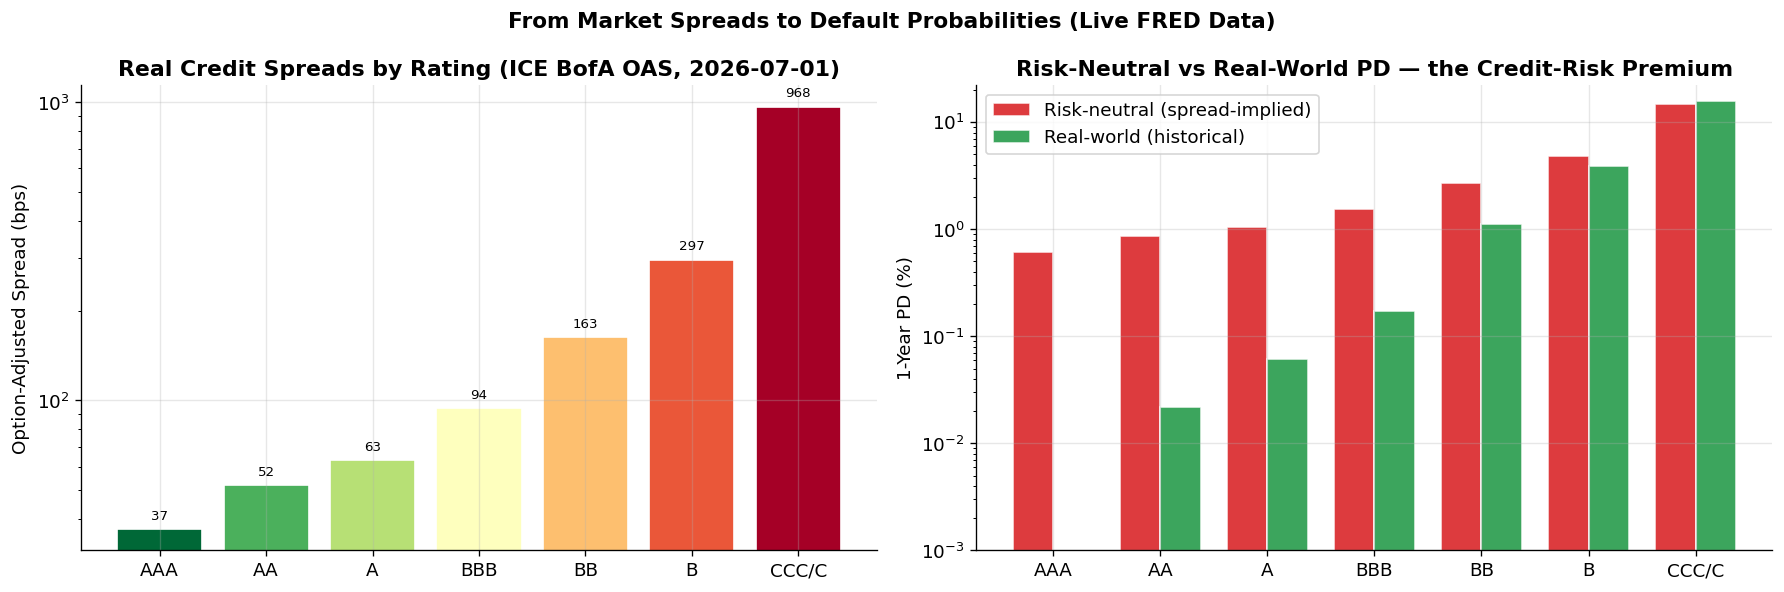


High grades: the market charges many times the historical default rate (risk premium).
Deep junk: the two PDs converge - most of a CCC spread really is expected default.


In [19]:
# ── Today's real credit spreads by rating (ICE BofA OAS via FRED, cached) ─────
fred = pd.read_csv(os.path.join(CACHE_DIR, "credit_spreads_fred.csv"),
                   index_col=0, parse_dates=True)
latest = fred.dropna(how='all').iloc[-1]
asof = fred.dropna(how='all').index[-1].date()
col_of = {'AAA':'AAA','AA':'AA','A':'A_','BBB':'BBB','BB':'BB','B':'B','CCC/C':'CCC'}
spread_pct = pd.Series({k: latest[v] for k,v in col_of.items()})     # % (annualised OAS)

LGD_SPREAD = 0.60                                    # senior-unsecured-ish
lam_rn  = spread_pct/100 / LGD_SPREAD
pd_rn   = (1 - np.exp(-lam_rn)) * 100                # risk-neutral 1-yr PD (%)

hist_map = {'AAA':'Aaa','AA':'Aa','A':'A','BBB':'Baa','BB':'Ba','B':'B','CCC/C':'Caa-C'}
pd_real  = pd.Series({k: cum_def.loc[v,'1'] for k,v in hist_map.items()})  # real-world (%)

tbl = pd.DataFrame({'Spread (bps)': (spread_pct*100).round(0),
                    'Risk-neutral PD (%)': pd_rn.round(2),
                    'Real-world PD (%)': pd_real.round(2)})
tbl['RN / Real ratio'] = (tbl['Risk-neutral PD (%)'] /
                          tbl['Real-world PD (%)'].replace(0, np.nan)).round(1)
print(f"Spread-implied (risk-neutral) vs historical (real-world) 1-year PD   [spreads as of {asof}]")
print("="*72); print(tbl.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = list(col_of.keys())
bar_c = [cm.RdYlGn(1.0 - i/(len(order)-1)) for i in range(len(order))]
axes[0].bar(order, spread_pct.values*100, color=bar_c, edgecolor='white')
axes[0].set_title(f'Real Credit Spreads by Rating (ICE BofA OAS, {asof})', fontweight='bold')
axes[0].set_ylabel('Option-Adjusted Spread (bps)'); axes[0].set_yscale('log')
for i,v in enumerate(spread_pct.values*100):
    axes[0].text(i, v*1.05, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

x = np.arange(len(order)); w = 0.38
axes[1].bar(x-w/2, pd_rn.values,  w, label='Risk-neutral (spread-implied)', color=RED,   alpha=0.85, edgecolor='white')
axes[1].bar(x+w/2, pd_real.values, w, label='Real-world (historical)',       color=GREEN, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(order); axes[1].set_yscale('log')
axes[1].set_ylabel('1-Year PD (%)'); axes[1].set_ylim(bottom=1e-3)
axes[1].set_title('Risk-Neutral vs Real-World PD — the Credit-Risk Premium', fontweight='bold')
axes[1].legend()
plt.suptitle('From Market Spreads to Default Probabilities (Live FRED Data)',
             fontsize=13, fontweight='bold'); plt.tight_layout(); plt.show()

print("\nHigh grades: the market charges many times the historical default rate (risk premium).")
print("Deep junk: the two PDs converge - most of a CCC spread really is expected default.")

---
## Part 12 - Valuing a Risky Bond in an Arbitrage-Free Framework

Parts 10 and 11 estimated a probability of default. Here we do the reverse of Part 11: start from a
PD and a recovery rate and **price the bond**, letting the credit spread fall out. This is the CFA
curriculum's *credit-risk model* (Adams), and it is exactly how a desk marks a risky bond consistently
with the risk-free curve.

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">The recipe</div>
<div style="color:#B8D4E8;line-height:1.7;">
<strong>1. VND</strong> - value the bond assuming <em>no default</em>, discounting its cash flows on the benchmark (risk-free) curve.<br>
<strong>2. Build a per-date table:</strong> expected <strong>exposure</strong> (the ex-default value at each date), <strong>LGD</strong> = exposure x (1 - recovery), the conditional default probability <strong>POD</strong> and survival <strong>POS</strong>, and the expected loss = LGD x POD.<br>
<strong>3. CVA</strong> = the present value of those expected losses (discounted on the benchmark curve).<br>
<strong>4.</strong> Fair value = <strong>VND - CVA</strong>; the bond's YTM at that price minus the benchmark yield is its <strong>credit spread</strong>.</div>
</div>

$$\text{POD}_t = h\cdot\text{POS}_{t-1},\qquad \text{CVA}=\sum_t \text{LGD}_t\cdot\text{POD}_t\cdot \text{DF}_t,\qquad \text{Fair value}=\text{VND}-\text{CVA}$$

*Reference: CFA Program, "Credit Analysis Models" (Adams). Benchmark = real US Treasury curve (FRED); hazard from a real market spread.*

In [20]:
from scipy.optimize import brentq

def risky_bond_cva(coupon_pct, T, bench_spot, hazard, recovery, face=100.0):
    """Arbitrage-free risky-bond valuation (CFA credit-risk model).
    bench_spot: list of annual benchmark spot rates for years 1..T (decimals)."""
    C  = coupon_pct/100*face
    cf = [C]*(T-1) + [C+face]                              # scheduled cash flows, years 1..T
    DF = [1/(1+bench_spot[t])**(t+1) for t in range(T)]
    VND = sum(cf[t]*DF[t] for t in range(T))              # value assuming no default
    exposure = []                                         # ex-default value at each date (cum-coupon)
    for t in range(1, T+1):
        v = cf[t-1]
        for k in range(t+1, T+1):
            v += cf[k-1]/(1+bench_spot[k-1])**(k-t)
        exposure.append(v)
    LGD = [e*(1-recovery) for e in exposure]
    POS, POD = 1.0, []
    for _ in range(T):
        p = hazard*POS; POD.append(p); POS -= p           # conditional (unconditional) default probs
    EL   = [LGD[t]*POD[t] for t in range(T)]
    PVEL = [EL[t]*DF[t] for t in range(T)]
    CVA  = sum(PVEL); fair = VND - CVA
    ytm  = brentq(lambda y: sum(cf[t]/(1+y)**(t+1) for t in range(T)) - fair, -0.5, 1.0)
    tbl = pd.DataFrame({'Exposure':exposure,'LGD':LGD,'POD(%)':[p*100 for p in POD],
                        'DF':DF,'PV(ExpLoss)':PVEL}, index=[f'Date {t}' for t in range(1,T+1)])
    return dict(VND=VND, CVA=CVA, fair=fair, ytm=ytm, table=tbl)

# --- Validate against the CFA textbook example (reproduces the published table) ---
# 3-year 8% annual bond, benchmark flat at 3%, annual PD 1.75%... use the exercise's 2% / 35%.
ex = risky_bond_cva(8.0, 3, [0.03]*3, hazard=0.02, recovery=0.35)
print("CFA 'Credit Risk Model' worked example (8% 3y bond, flat 3%, PD 2%, recovery 35%)")
print(ex['table'].round(4).to_string())
print(f"\n  VND = {ex['VND']:.4f}   CVA = {ex['CVA']:.4f}  (CFA table: 4.0731)")
print(f"  Fair value = {ex['fair']:.4f}   YTM = {ex['ytm']*100:.4f}%   credit spread = {(ex['ytm']-0.03)*1e4:.1f} bp")
assert abs(ex['CVA'] - 4.0731) < 0.01, "CVA should reproduce the CFA figure"
print("  -> matches the published CVA of 4.0731.")

CFA 'Credit Risk Model' worked example (8% 3y bond, flat 3%, PD 2%, recovery 35%)
        Exposure      LGD  POD(%)      DF  PV(ExpLoss)
Date 1  117.5673  76.4188  2.0000  0.9709       1.4839
Date 2  112.8544  73.3553  1.9600  0.9426       1.3552
Date 3  108.0000  70.2000  1.9208  0.9151       1.2340

  VND = 114.1431   CVA = 4.0731  (CFA table: 4.0731)
  Fair value = 110.0700   YTM = 4.3473%   credit spread = 134.7 bp
  -> matches the published CVA of 4.0731.


Real US Treasury benchmark (FRED 2026-07-01): 1y 4.00%, 2y 4.17%, 3y 4.19%, 4y 4.21%, 5y 4.24%

5-year 5.50% BBB bond | market BBB OAS 94bp -> hazard 1.57%/yr, recovery 40%
        Exposure      LGD  POD(%)      DF  PV(ExpLoss)
Date 1  110.0598  66.0359  1.5667  0.9615       0.9948
Date 2  108.9857  65.3914  1.5421  0.9215       0.9293
Date 3  107.8696  64.7218  1.5180  0.8841       0.8686
Date 4  106.7087  64.0252  1.4942  0.8478       0.8110
Date 5  105.5000  63.3000  1.4708  0.8125       0.7564

  VND (risk-free value)  = 105.6021
  CVA (credit charge)    = 4.3602   (413 bp of value)
  Fair value             = 101.2420
  Extracted credit spread= 98 bp   vs market BBB OAS 94 bp
  The arbitrage-free spread round-trips to roughly the market spread we fed in - the
  CVA model and the s = lambda x LGD shortcut agree, and the CVA is that spread capitalised.


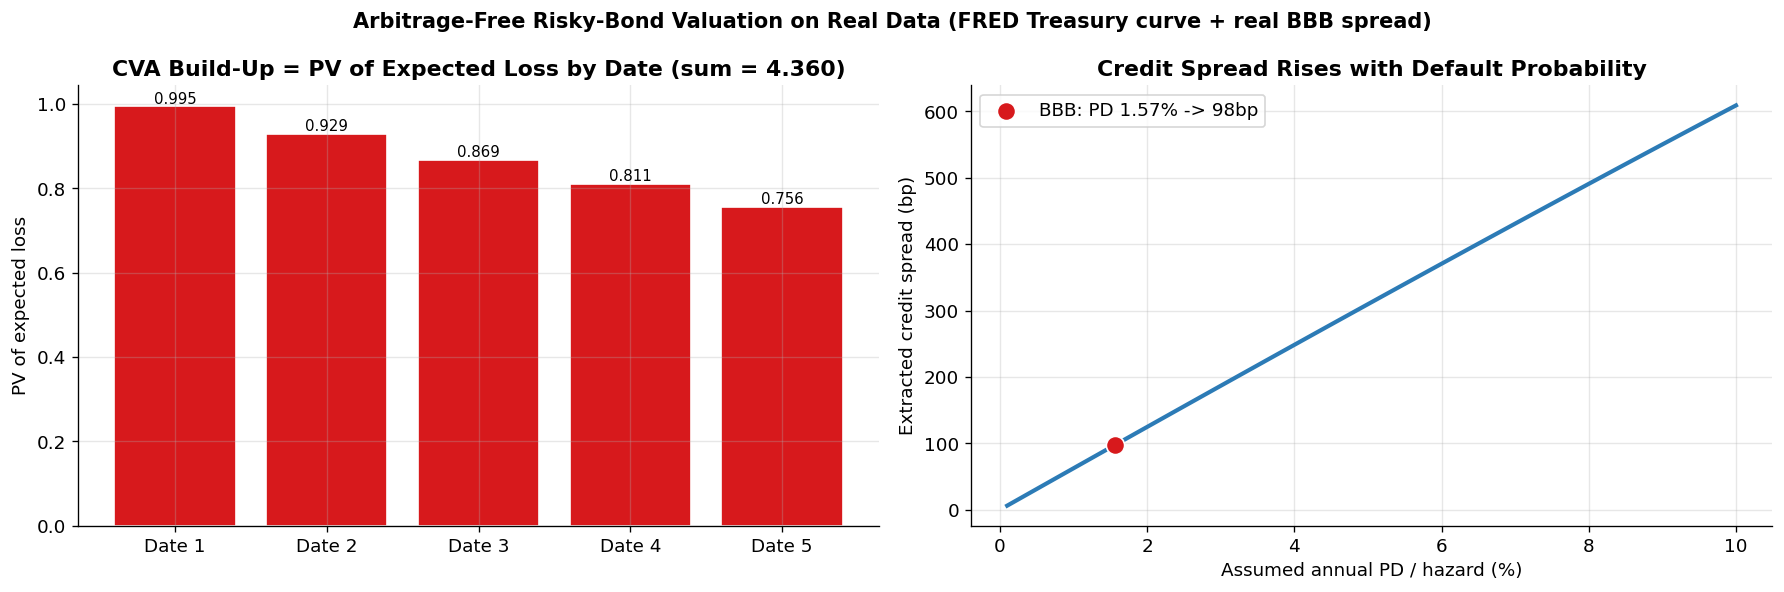

In [21]:
# --- Same engine, real data: real Treasury benchmark + real spread-implied hazard ---
tsy = pd.read_csv(os.path.join(CACHE_DIR, "treasury_curve_fred.csv"), index_col=0)
tsy.columns = [int(c) for c in tsy.columns]
asof_t = tsy.index.name.replace('asof_','')
# spot rates for years 1..5 (linearly interpolate the 4y point), in decimals
yrs = [1,2,3,4,5]
tk = tsy.iloc[0]
bench5 = [tk[1]/100, tk[2]/100, tk[3]/100, (tk[3]+tk[5])/2/100, tk[5]/100]
print(f"Real US Treasury benchmark (FRED {asof_t}): " + ", ".join(f"{y}y {bench5[i]*100:.2f}%" for i,y in enumerate(yrs)))

# BBB corporate: hazard from today's real BBB market spread (OAS/LGD), recovery 40%
oas_bbb = float(pd.read_csv(os.path.join(CACHE_DIR,"credit_spreads_fred.csv"),
                index_col=0, parse_dates=True).dropna(how='all').iloc[-1]['BBB'])   # % (e.g. 0.94)
REC_B = 0.40; LGD_B = 1-REC_B
h_bbb = oas_bbb/100/LGD_B                                    # market-implied annual hazard
COUP  = 5.50                                                 # 5.5% annual coupon, 5-year BBB bond

res = risky_bond_cva(COUP, 5, bench5, hazard=h_bbb, recovery=REC_B)
bench_ytm = brentq(lambda y: sum(([COUP]*4+[COUP+100])[t]/(1+y)**(t+1) for t in range(5))
                   - sum(([COUP]*4+[COUP+100])[t]*(1/(1+bench5[t])**(t+1)) for t in range(5)), -0.5, 1)
spread_bp = (res['ytm']-bench_ytm)*1e4
print(f"\n5-year {COUP:.2f}% BBB bond | market BBB OAS {oas_bbb*100:.0f}bp -> hazard {h_bbb*100:.2f}%/yr, recovery {REC_B:.0%}")
print(res['table'].round(4).to_string())
print(f"\n  VND (risk-free value)  = {res['VND']:.4f}")
print(f"  CVA (credit charge)    = {res['CVA']:.4f}   ({res['CVA']/res['VND']*1e4:.0f} bp of value)")
print(f"  Fair value             = {res['fair']:.4f}")
print(f"  Extracted credit spread= {spread_bp:.0f} bp   vs market BBB OAS {oas_bbb*100:.0f} bp")
print("  The arbitrage-free spread round-trips to roughly the market spread we fed in - the")
print("  CVA model and the s = lambda x LGD shortcut agree, and the CVA is that spread capitalised.")

# --- Plots: CVA build-up by date, and extracted spread vs assumed PD ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
t_lab = list(res['table'].index)
axes[0].bar(t_lab, res['table']['PV(ExpLoss)'], color=RED, edgecolor='white')
axes[0].set_title(f"CVA Build-Up = PV of Expected Loss by Date (sum = {res['CVA']:.3f})", fontweight='bold')
axes[0].set_ylabel("PV of expected loss")
for i,v in enumerate(res['table']['PV(ExpLoss)']):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

pds = np.linspace(0.001, 0.10, 40)
sp  = []
for p in pds:
    rr = risky_bond_cva(COUP, 5, bench5, hazard=p, recovery=REC_B)
    yy = brentq(lambda y: sum(([COUP]*4+[COUP+100])[t]/(1+y)**(t+1) for t in range(5)) - rr['fair'], -0.5, 1)
    sp.append((yy-bench_ytm)*1e4)
axes[1].plot(pds*100, sp, color=BLUE, lw=2.5)
axes[1].scatter([h_bbb*100], [spread_bp], s=120, color=RED, zorder=5, edgecolors='white',
                label=f'BBB: PD {h_bbb*100:.2f}% -> {spread_bp:.0f}bp')
axes[1].set_xlabel("Assumed annual PD / hazard (%)"); axes[1].set_ylabel("Extracted credit spread (bp)")
axes[1].set_title("Credit Spread Rises with Default Probability", fontweight='bold'); axes[1].legend()
plt.suptitle("Arbitrage-Free Risky-Bond Valuation on Real Data (FRED Treasury curve + real BBB spread)",
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()

---
## Part 13 - Expected Return from Credit Migration

A bond's one-year return is not just its yield. Its **rating can drift**, and when it does, its spread
(and therefore its price) moves. Using spread / modified duration to translate a spread change into a
price change, and weighting by the one-year transition probabilities, we get the expected contribution
of **rating migration** to return - and its distribution.

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">The calculation (CFA Ch.10, Exercise 2)</div>
<div style="color:#B8D4E8;line-height:1.7;">
For each possible end-rating j, the price change is <strong>&Delta;P<sub>j</sub> &asymp; -D &times; (s<sub>j</sub> - s<sub>i</sub>)</strong>
(modified duration D times the change in spread). A move to <strong>default</strong> takes the price down to recovery.
The probability-weighted sum is the expected migration return - a lightweight, duration-based cousin of the full
CreditMetrics revaluation from Session 6.</div>
</div>

$$E[\Delta P]=\sum_{j\neq D} p_{i\to j}\,\big(-D\,(s_j-s_i)\big)\;+\;p_{i\to D}\,\big(-(1-R)\big)$$

*Uses the real S&P 1981-2024 transition matrix and today's real market spreads by rating (FRED); reproduces the CFA worked example first.*

In [22]:
# --- Reproduce the CFA Exercise 2 worked example (illustrative matrix + spreads) ---
mig_states = ['AAA','AA','A','BBB','BB','B','CCC','D']
bbb_row_cfa = [0.02, 0.30, 4.80, 85.50, 6.95, 1.75, 0.45, 0.23]        # % transition probs
spr_cfa     = [0.60, 0.90, 1.10, 1.50, 3.40, 6.50, 9.50, None]         # 10y credit spreads (%)
DUR = 7.0                                                              # modified/spread duration
s_now = spr_cfa[mig_states.index('BBB')]                              # 1.50%
dP_cfa = [(-DUR*(s - s_now)) if s is not None else None for s in spr_cfa]
exp_cfa = sum(bbb_row_cfa[i]/100*dP_cfa[i] for i in range(7))          # exclude default (as the CFA text does)

print("CFA Ex.2: 10-year BBB bond, modified duration 7.0, one-year migration")
print(f"{'-> rating':10s} {'prob %':>8s} {'spread %':>9s} {'price chg %':>12s}")
for i,st in enumerate(mig_states):
    s = spr_cfa[i]; dp = dP_cfa[i]
    print(f"{st:10s} {bbb_row_cfa[i]:8.2f} {('' if s is None else f'{s:.2f}'):>9s} {('default' if dp is None else f'{dp:+.2f}'):>12s}")
print(f"\nExpected 1-year price change from migration = {exp_cfa:.2f}%   (CFA answer: -1.64%)")
assert abs(exp_cfa - (-1.64)) < 0.02
print("-> reproduces the textbook -1.64%. The one-year expected return is the bond's YTM minus 1.64%.")

CFA Ex.2: 10-year BBB bond, modified duration 7.0, one-year migration
-> rating    prob %  spread %  price chg %
AAA            0.02      0.60        +6.30
AA             0.30      0.90        +4.20
A              4.80      1.10        +2.80
BBB           85.50      1.50        -0.00
BB             6.95      3.40       -13.30
B              1.75      6.50       -35.00
CCC            0.45      9.50       -56.00
D              0.23                default

Expected 1-year price change from migration = -1.64%   (CFA answer: -1.64%)
-> reproduces the textbook -1.64%. The one-year expected return is the bond's YTM minus 1.64%.


Real 10-year BBB bond, duration 7.0, one-year migration (S&P 1981-2024, spreads 2026-07-01)
-> rating    prob %  spread bp  price chg %
AAA            0.00         37        +3.99
AA             0.07         52        +2.94
A              3.23         63        +2.17
BBB           92.62         94        -0.00
BB             3.40        163        -4.83
B              0.42        297       -14.21
CCC/C          0.10        968       -61.18
D              0.15    default       -60.00

Expected migration price change = -0.30%   stdev 3.26%   1%-tail 'migration VaR' 4.5%
Small expected drag today (tight spreads + a stable BBB row), but a fat downside: a jump to
CCC or default costs ~60%. This is CreditMetrics in miniature - migration risk, not just default.


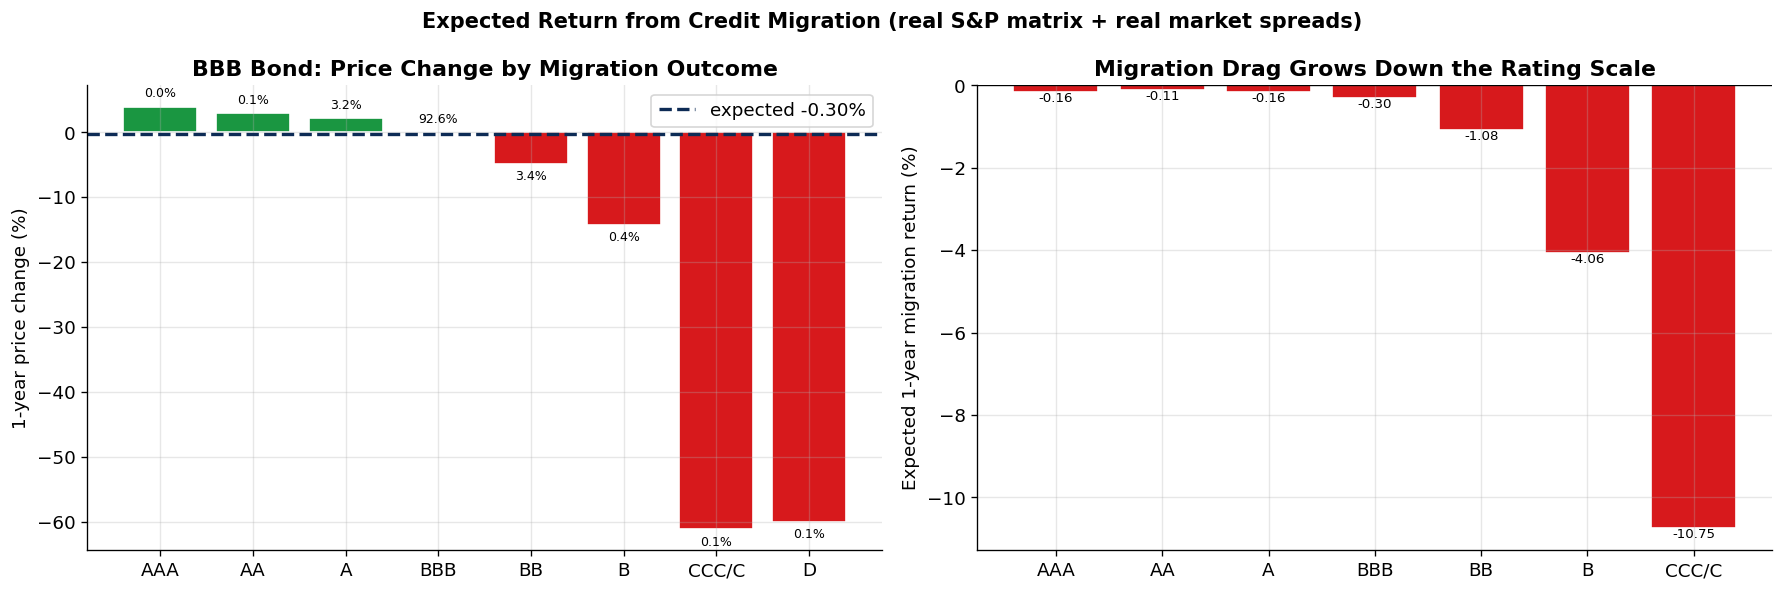

In [23]:
# --- Same calc on REAL data: S&P 1981-2024 matrix + today's real market spreads ---
tr = pd.read_csv(os.path.join(CACHE_DIR, "sp_transition_1981_2024.csv"), index_col=0)
fr = pd.read_csv(os.path.join(CACHE_DIR, "credit_spreads_fred.csv"),
                 index_col=0, parse_dates=True).dropna(how='all')
asof = fr.index[-1].date(); fr = fr.iloc[-1]
col = {'AAA':'AAA','AA':'AA','A':'A_','BBB':'BBB','BB':'BB','B':'B','CCC/C':'CCC'}
spr = {r: float(fr[c]) for r,c in col.items()}                        # real OAS by rating (%)
REC_M = 0.40
sp_states = ['AAA','AA','A','BBB','BB','B','CCC/C','D']

def migration_return(start, D=DUR):
    row = tr.loc[start, sp_states].values.astype(float); row = row/row.sum()   # drop NR, renormalise
    s0 = spr[start]
    dP = [(-D*(spr[st]-s0)) for st in sp_states[:-1]] + [-(1-REC_M)*100]        # default -> recovery
    mean = float((row*np.array(dP)).sum())
    sd   = float(np.sqrt((row*(np.array(dP)-mean)**2).sum()))
    o = np.argsort(dP); cp = np.cumsum(row[o]); q1 = np.array(dP)[o][np.searchsorted(cp,0.01)]
    return row, dP, mean, sd, mean-q1

row, dP, mean, sd, mvar = migration_return('BBB')
print(f"Real 10-year BBB bond, duration {DUR}, one-year migration (S&P 1981-2024, spreads {asof})")
print(f"{'-> rating':10s} {'prob %':>8s} {'spread bp':>10s} {'price chg %':>12s}")
for i,st in enumerate(sp_states):
    sp_txt = f"{spr.get(st, float('nan'))*100:.0f}" if st!='D' else 'default'
    print(f"{st:10s} {row[i]*100:8.2f} {sp_txt:>10s} {dP[i]:+12.2f}")
print(f"\nExpected migration price change = {mean:+.2f}%   stdev {sd:.2f}%   1%-tail 'migration VaR' {mvar:.1f}%")
print("Small expected drag today (tight spreads + a stable BBB row), but a fat downside: a jump to")
print("CCC or default costs ~60%. This is CreditMetrics in miniature - migration risk, not just default.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = [GREEN if d>=0 else RED for d in dP]
bars = axes[0].bar(sp_states, dP, color=cols, edgecolor='white')
axes[0].axhline(mean, color=NAVY, lw=2, ls='--', label=f'expected {mean:+.2f}%')
axes[0].set_ylabel('1-year price change (%)'); axes[0].set_title('BBB Bond: Price Change by Migration Outcome', fontweight='bold')
for i,d in enumerate(dP):
    axes[0].text(i, d + (1 if d>=0 else -1), f'{row[i]*100:.1f}%', ha='center',
                 va='bottom' if d>=0 else 'top', fontsize=7.5)
axes[0].legend()

start_r = ['AAA','AA','A','BBB','BB','B','CCC/C']
exps = [migration_return(s)[2] for s in start_r]
axes[1].bar(start_r, exps, color=[GREEN if e>=0 else RED for e in exps], edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Expected 1-year migration return (%)')
axes[1].set_title('Migration Drag Grows Down the Rating Scale', fontweight='bold')
for i,e in enumerate(exps):
    axes[1].text(i, e, f'{e:+.2f}', ha='center', va='bottom' if e>=0 else 'top', fontsize=8)
plt.suptitle('Expected Return from Credit Migration (real S&P matrix + real market spreads)',
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()

---
## Your Turn — Practice Exercises

<div style="border-left:6px solid #8E44AD;background:#150820;padding:16px 22px;border-radius:0 8px 8px 0;margin:14px 0;">
<div style="color:#C39BD3;font-size:0.78em;font-weight:700;letter-spacing:0.07em;margin-bottom:5px;">PRACTICE EXERCISES</div>
<div style="color:#E8DAEF;font-weight:600;font-size:1.02em;margin-bottom:8px;">Estimate one firm's default risk four different ways</div>
<div style="color:#D7BDE2;line-height:1.75;">Complete Parts A-E with <strong>two stocks of your choice</strong>. Parts A-E use the Merton
model; then, for Part F, pick <em>one</em> of the new tools and apply it to the same firm — the
Altman Z-score from its financials, its rating-implied PD from the real S&amp;P matrix, or its
spread-implied PD from a traded bond/CDS spread. Compare all the PDs you obtain and reconcile them.</div>
</div>

### Part A — Data Setup
Choose two tickers. Retrieve or hard-code their equity value, total debt, and annualised equity volatility.

### Part B — Merton Calibration
Run `merton_calibrate()` on each firm. Report V, σ_V, DD, and the risk-neutral PD.

### Part C — Credit Spread
Compute the 1-year credit spread (in basis points) for each firm assuming LGD = 45%.

### Part D — Sensitivity
For one firm, plot how PD changes as total debt rises from 50% to 200% of its current value.

### Part E — Rating comparison
Look up each firm's S&P rating and compare the **rating-implied PD** (`rating_to_pd`, real S&P
frequencies) with your Merton PD. What might explain any gap?

### Part F — Pick a second model (choose one)
Compute a PD for one firm with **either** the Altman Z-score (Part 9), **or** a spread-implied PD
(Part 11) using a real bond/CDS spread you look up. Put all your PDs for that firm side by side and
write 2-3 sentences reconciling structural, accounting, rating, and market views.

In [24]:
# ── Part A — Choose your two tickers ─────────────────────────────────────────
MY_TICKERS = ['TICKER1', 'TICKER2']   # ← replace with your choices

my_firm_data = {}
for ticker in MY_TICKERS:
    # Hard-coded fallback — fill in real values or let yfinance retrieve them
    market_cap = 100e9   # ← replace
    total_debt  = 30e9   # ← replace

    try:
        tk   = yf.Ticker(ticker)
        info = tk.info
        mc_live = info.get('marketCap')
        if mc_live and mc_live > 1e8:
            market_cap = float(mc_live)
        td_live = info.get('totalDebt')
        if td_live and td_live > 0:
            total_debt = float(td_live)
    except Exception:
        pass

    # Download price history to estimate equity vol
    try:
        raw_my = yf.download(ticker, start=START, end=END,
                             auto_adjust=True, progress=False)
        px_my  = raw_my['Close'].squeeze().dropna()
        sigma_e_my = float(np.log(px_my/px_my.shift(1)).dropna().std() * np.sqrt(252))
    except Exception:
        sigma_e_my = 0.25   # fallback vol

    my_firm_data[ticker] = {
        'E': market_cap, 'D': total_debt, 'sigma_E': sigma_e_my
    }
    print(f"{ticker}: E=${market_cap/1e9:.1f}B, D=${total_debt/1e9:.1f}B, σ_E={sigma_e_my*100:.1f}%")

Failed to get ticker 'TICKER1' reason: 'str' object has no attribute 'name'

1 Failed download:
['TICKER1']: AttributeError("'str' object has no attribute 'name'")
Failed to get ticker 'TICKER2' reason: 'str' object has no attribute 'name'

1 Failed download:
['TICKER2']: AttributeError("'str' object has no attribute 'name'")


TICKER1: E=$100.0B, D=$30.0B, σ_E=nan%
TICKER2: E=$100.0B, D=$30.0B, σ_E=nan%


In [25]:
# ── Part B — Merton Calibration ───────────────────────────────────────────────
# YOUR CODE HERE
# For each ticker in MY_TICKERS, call merton_calibrate() and print DD and PD

for ticker in MY_TICKERS:
    d = my_firm_data[ticker]
    # YOUR CODE HERE
    pass

In [26]:
# ── Part C — Credit Spread ────────────────────────────────────────────────────
# YOUR CODE HERE
# Compute the 1-year credit spread in basis points for each firm
# Use: spread_bps = -log(1 - PD * LGD) / T * 10000

LGD_C = 0.45
for ticker in MY_TICKERS:
    d = my_firm_data[ticker]
    # YOUR CODE HERE
    pass

In [27]:
# ── Part D — Leverage Sensitivity ─────────────────────────────────────────────
# YOUR CODE HERE
# Pick one ticker. Scale its total debt from 50% to 200% of the current value.
# For each scaled debt level, run merton_calibrate() and record PD.
# Plot PD vs the leverage ratio D/(E+D).

chosen_ticker = MY_TICKERS[0]
d_base = my_firm_data[chosen_ticker]
D_base = d_base['D']
debt_multipliers = np.linspace(0.5, 2.0, 30)

# YOUR CODE HERE
pds_leverage = []
for mult in debt_multipliers:
    # YOUR CODE HERE
    pass

In [28]:
# ── Part E — Rating Comparison & Interpretation ───────────────────────────────
# YOUR CODE HERE
# 1. Look up each firm's S&P rating and find the rating-implied PD from rating_to_pd
# 2. Compare with the Merton PD from Part B
# 3. Write 2–3 sentences interpreting the gap (or lack of gap)

my_ratings = {
    MY_TICKERS[0]: 'A',    # ← replace with actual rating
    MY_TICKERS[1]: 'BBB',  # ← replace with actual rating
}

for ticker in MY_TICKERS:
    rtg   = my_ratings[ticker]
    pd_rt = rating_to_pd.get(rtg, np.nan)
    print(f"{ticker}: Rating={rtg}, Rating-PD={pd_rt*100:.4f}%")
    # YOUR CODE HERE: print Merton PD and compare

# Your written interpretation here:
# (replace with your analysis)
interpretation = """
YOUR INTERPRETATION HERE:
Compare the Merton PD and rating-implied PD for each firm.
Discuss what economic factors might explain the gap.
"""
print(interpretation)

TICKER1: Rating=A, Rating-PD=0.0500%
TICKER2: Rating=BBB, Rating-PD=0.1400%

YOUR INTERPRETATION HERE:
Compare the Merton PD and rating-implied PD for each firm.
Discuss what economic factors might explain the gap.



---
## Session Summary

Four complementary lenses on the same question — *how likely is default?*

| Approach | Method | Best for |
|----------|--------|----------|
| **Structural (Merton)** | Equity as a call on assets; PD $=N(-\text{DD})$ | Listed firms with traded equity |
| **Ratings / transitions** | Real S&P 1-yr matrix + Moody's default rates | Through-the-cycle anchor, migration risk |
| **Accounting (Altman Z)** | Discriminant score from balance-sheet ratios | Firms with financials but no clean market signal |
| **Statistical scorecard** | Logistic regression on outcomes (UCI, AUC≈0.71) | Retail / SME books, thousands of borrowers |
| **Market spreads** | $\lambda\approx s/\text{LGD}$, $\text{PD}=1-e^{-\lambda}$ | Real-time, risk-neutral; bridges to intensity models |

Key distinction carried into Session 6: **risk-neutral PD (from spreads) is systematically larger
than real-world PD (from history)** — the credit-risk premium.

**Next session:** intensity (reduced-form) models, CDS bootstrapping, and portfolio credit risk —
Gaussian copula, Vasicek, **CreditMetrics** (using this session's real transition matrix), and **CreditRisk+**.